# Telco Customer Churn Analysis & Prediction

## Project Overview
Welcome to this comprehensive analysis of the Telco Customer Churn dataset! 

**Goal:** The primary objective is to predict whether a customer will leave the company (Churn) based on their profile and service history. By identifying at-risk customers early, businesses can take proactive retention measures.

**Approach:**
1. **Exploratory Data Analysis (EDA):** Get familiar with the data, spot patterns, and identify any issues like missing values or imbalances
2. **Data Preprocessing:** Clean the data, handle categorical variables, scale features, and prepare it for modeling.
3.**Modeling:** Start with baseline classification models to set a benchmark, then select a few promising ones for hyperparameter tuning using RandomizedSearchCV (for broad exploration) and GridSearchCV (for fine-tuning).
4. **Evaluation:** Use metrics like AUC-ROC (for overall performance), Recall (important for catching churners),and F1-Score (balance between precision and recall).

Why this approach? Starting with baselines gives quick insights without overcomplicating things. Tuning with Randomized + Grid search is efficient for finding optimal params—pros: saves time compared to full grid search alone, cons: still computationally intensive, but worth it for better results.

## Data Description
The dataset has 7043 rows (customers) and 21 columns. It's a classic Kaggle dataset for binary classification.
| Feature Category | Description | Key Columns |
| :--- | :--- | :--- |
| **Demographics** | Customer profile information | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| **Services** | Which services the customer has signed up for | `PhoneService`, `InternetService`, `StreamingTV`, `TechSupport` |
| **Account** | Contract and payment details | `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges` |
| **Target** | The variable we want to predict | `Churn` (Yes/No) |


# Import libraries and data

In [1]:
# Data Manipulation
import numpy as np  
import pandas as pd 
import math         

# Data Visualization
import matplotlib.pyplot as plt   
import seaborn as sns            

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder     
from sklearn.preprocessing import StandardScaler  
from sklearn.compose import ColumnTransformer      # Apply transformers to specific columns
from sklearn.pipeline import Pipeline              # Chain preprocessing + model training

# Statistical Analysis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Feature Selection
from sklearn.feature_selection import chi2

# Model Training 
from sklearn.model_selection import train_test_split    # Split data into training & test sets
from sklearn.linear_model import LogisticRegression     # Logistic regression model
from sklearn.ensemble import RandomForestClassifier     # Ensemble-based tree model
from sklearn.neighbors import KNeighborsClassifier      # KNN classifier
from xgboost import XGBClassifier                       # Gradient boosting model (XGBoost)
from lightgbm import LGBMClassifier                     # Gradient boosting model (LightGBM)

# Model Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,        
    classification_report,  
    roc_auc_score,           
    roc_curve,               
    f1_score              
)

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint, uniform   # Distributions for RandomizedSearchCV

# Warnings Handling
import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # Suppress unnecessary warnings


In [2]:
# Applying a default style for all plots
sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Let's Explore the Data!
Before diving into models, it's crucial to understand our dataset. We'll check for missing values, analyze the distribution of our target variable `Churn`, and look for correlations between features.

# Exploratory Data Analysis (EDA)

## Data Overview

In [4]:
# Checking on the datatypes and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [6]:
# Checking for duplicated rows
df.duplicated().sum()

np.int64(0)

In [7]:
# Looking at the statistical summary for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Notes:
- `TotalCharges` data type need to be changed to float
- Most of the categorical columns seems to have the right ammount of unique values but some need checking like `PaymentMethod`
- `SeniorCitezen` is a binary categorical column so it's data type can stay as int but we will change it to "yes" and "no" to be easier at analysis
- The distribution of the numerical columns looks fine and isn't much skewed

In [8]:
# There are some blank cells in TotalCharges with only spaces " " in it 
# so we gave it errors='coerce' to force the converting with changing the blank cells to NaN
df['TotalCharges'] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df['TotalCharges'].isna().sum()

np.int64(11)

- Now there is some null values in `TotalCharges` but they represent tiny amount from the data set 11/7043, so it won't matter alot if we just dropped these rows, but it's better to imput it
- We can notice that we can get the value of `TotalCahrges` as it is the product of `tenure` and `MonthlyCharges`

In [9]:
df[['MonthlyCharges', 'tenure', 'TotalCharges']].sample(10)

,MonthlyCharges,tenure,TotalCharges
477,75.70,7,554.05
6562,100.20,14,1369.80
1455,106.05,36,3834.40
1252,19.45,1,19.45
2547,39.10,52,1982.10
2310,63.70,72,4464.80
87,20.65,48,1057.00
4488,74.15,42,3229.40
4647,45.25,4,155.35
1743,24.85,67,1583.50


In [10]:
# Imputing the missing values in TotalCharges
df['TotalCharges'].fillna((df['tenure'] * df['MonthlyCharges']), inplace=True)
df['TotalCharges'].isna().sum()

C:\Users\Youssif\AppData\Local\Temp\ipykernel_21324\2881143547.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna((df['tenure'] * df['MonthlyCharges']), inplace=True)


np.int64(0)

Now we need to check on some categorical columns to make sure their data are consistent

In [11]:
# Checking on the unique values for PaymentMethod
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

It looks perfect and we can say that the rest of the categorical columns have a realistic amount of unique values.
But if their was a wrong value it would appear in the next steps so we won't need to check the unique values of each column now.

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [13]:
# Converting SeniorCitizen column to categorical
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:'no', 1:'yes'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Further Analysis and Visualizations

In [14]:
# Separating categorical and numerical columns (Our target column "Churn" will be separated from both)
cat_cols = df.select_dtypes(include='object').columns.drop(['Churn', 'customerID']).tolist()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

### Visualizing distributions

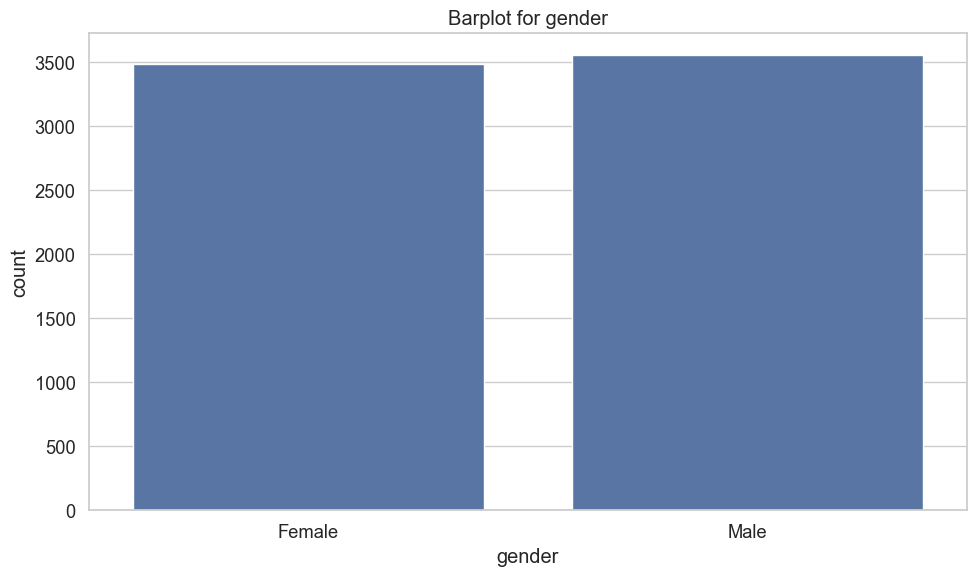

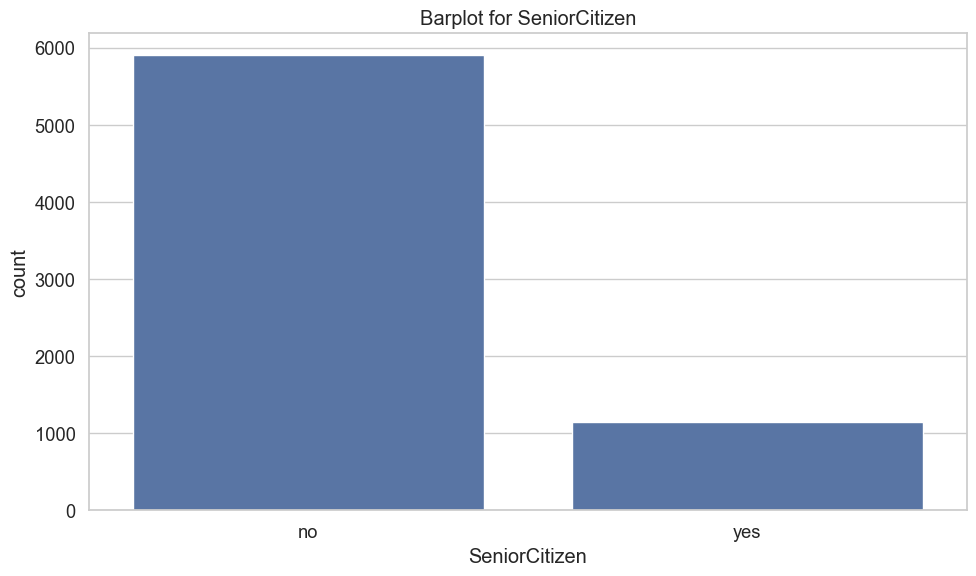

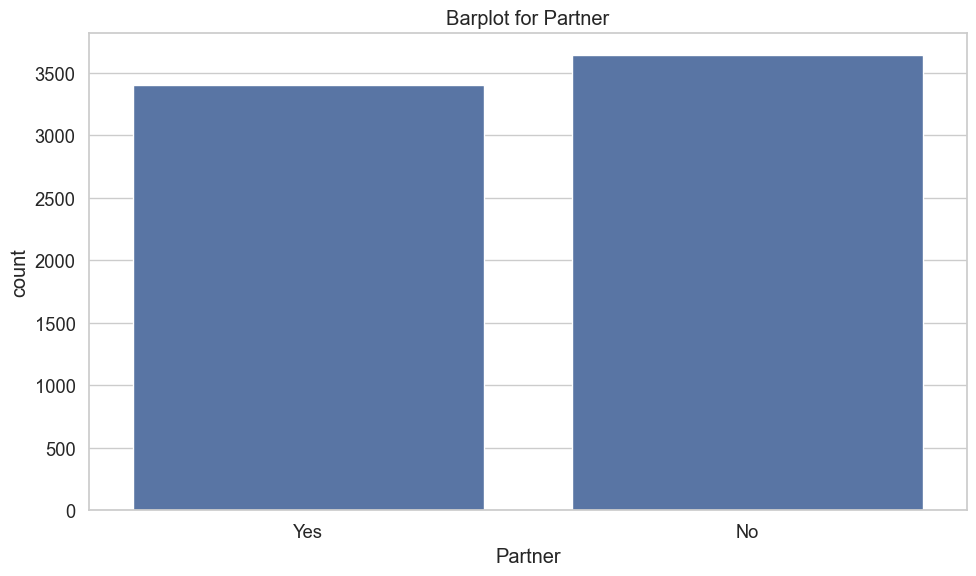

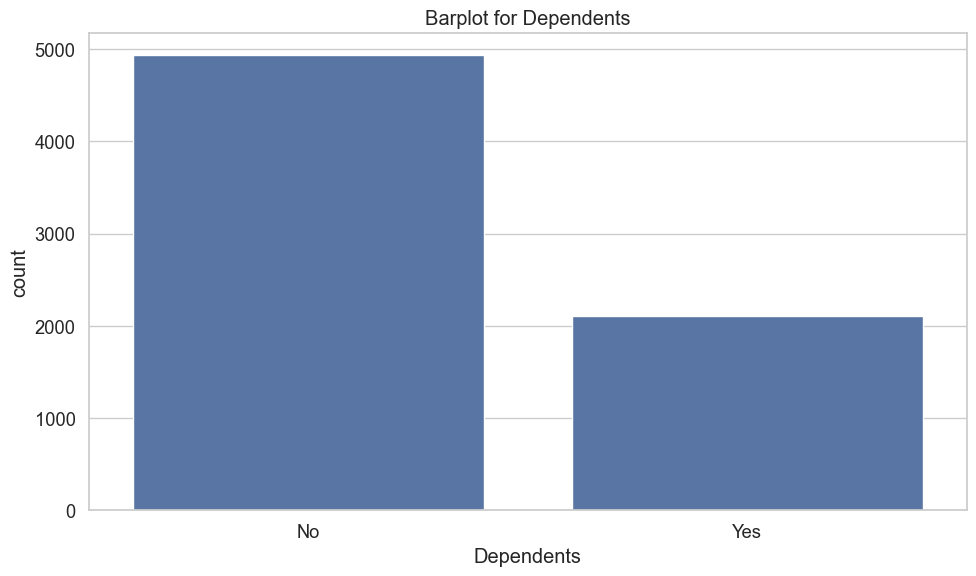

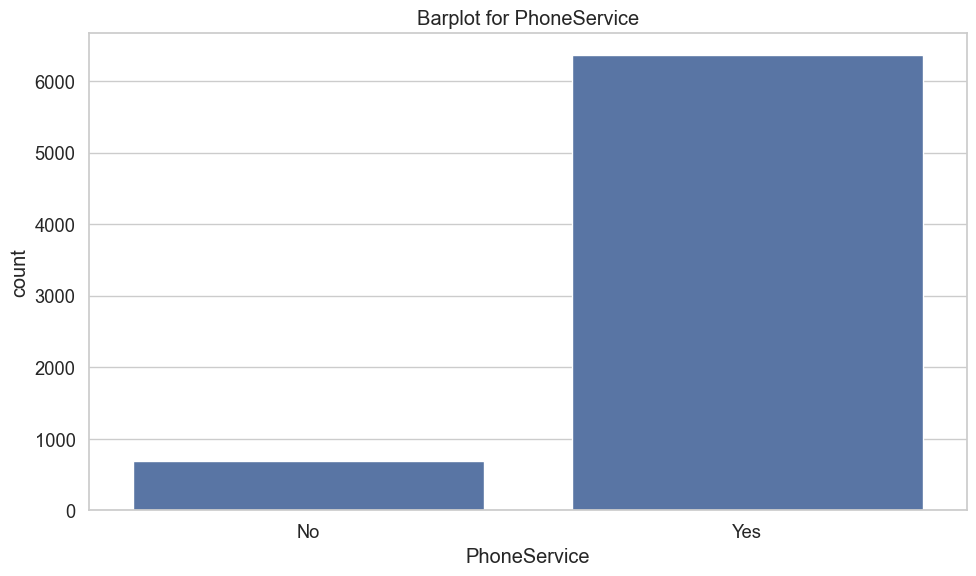

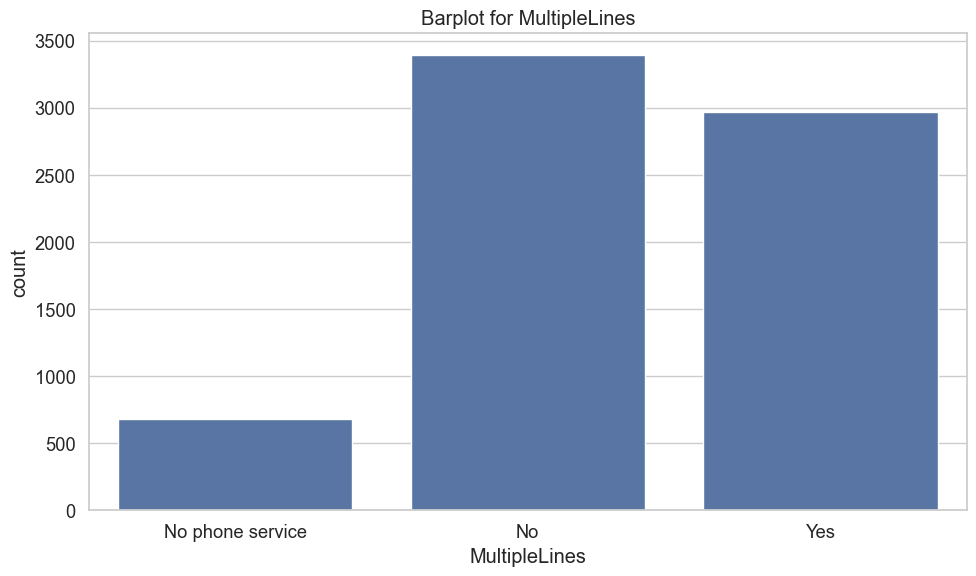

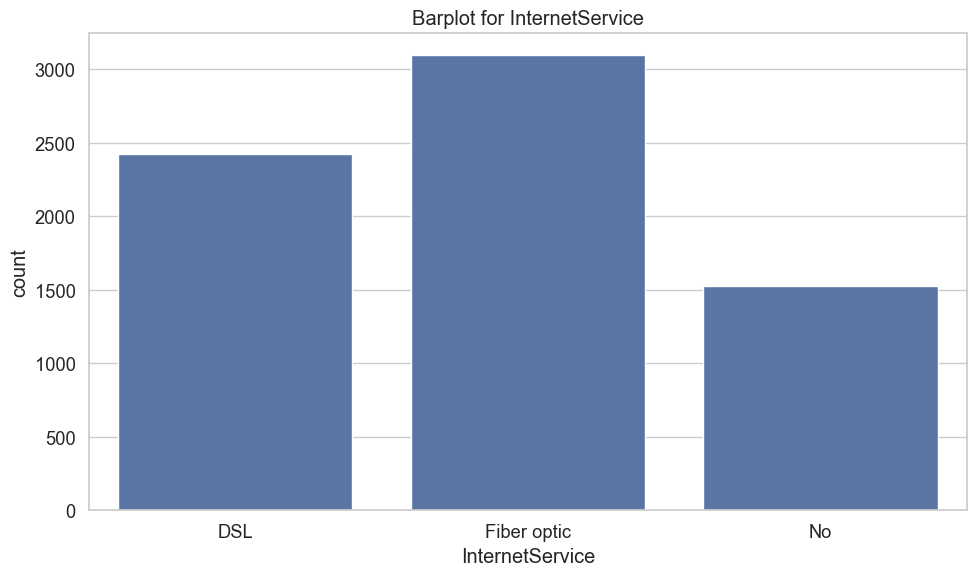

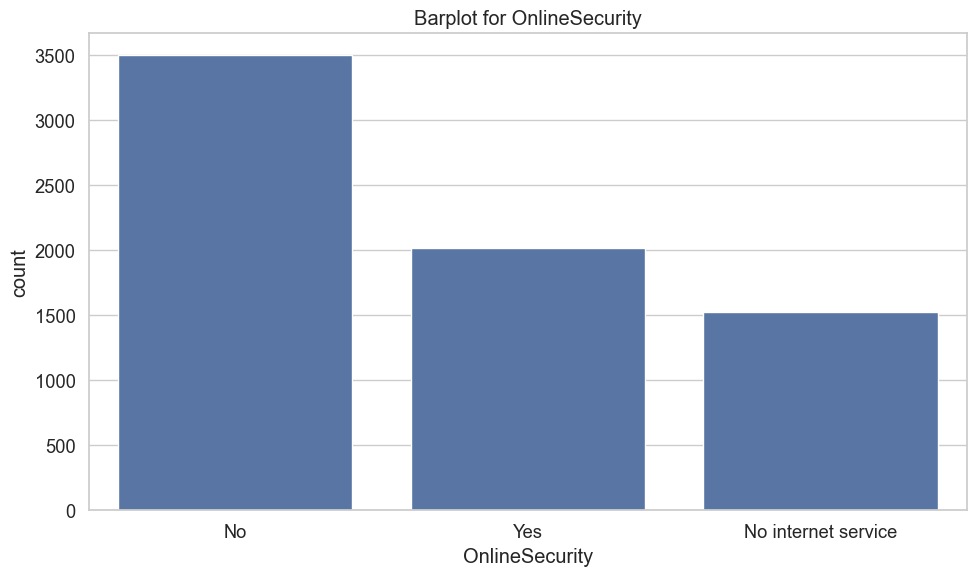

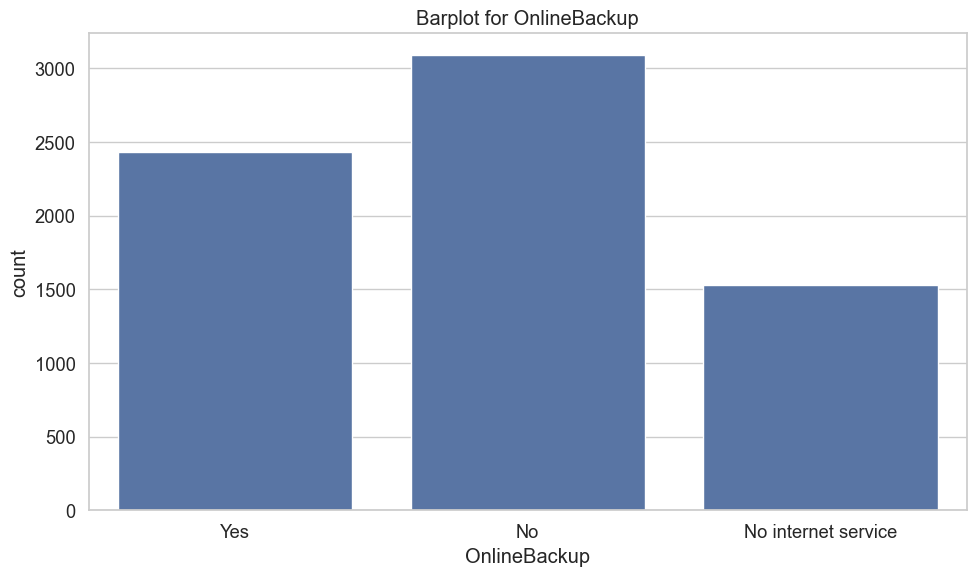

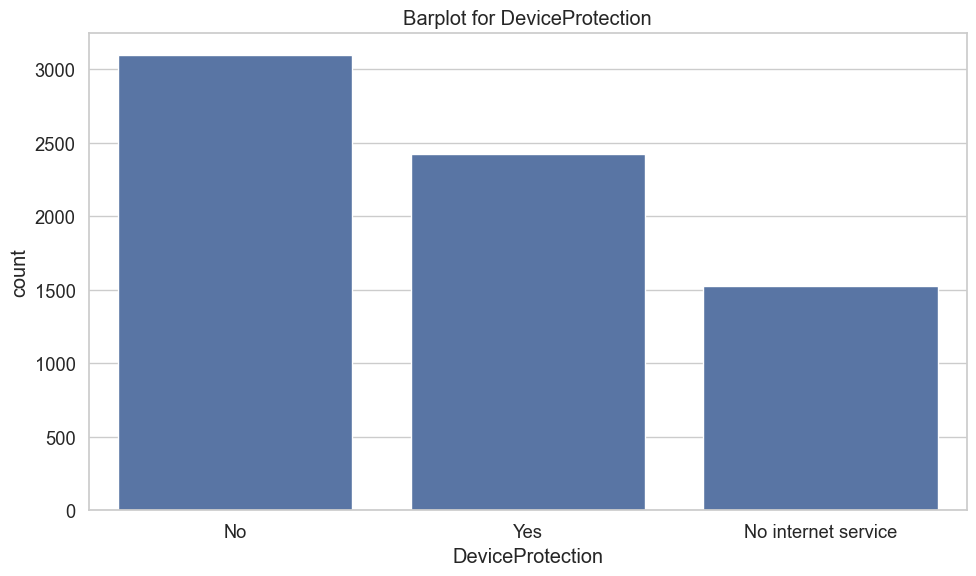

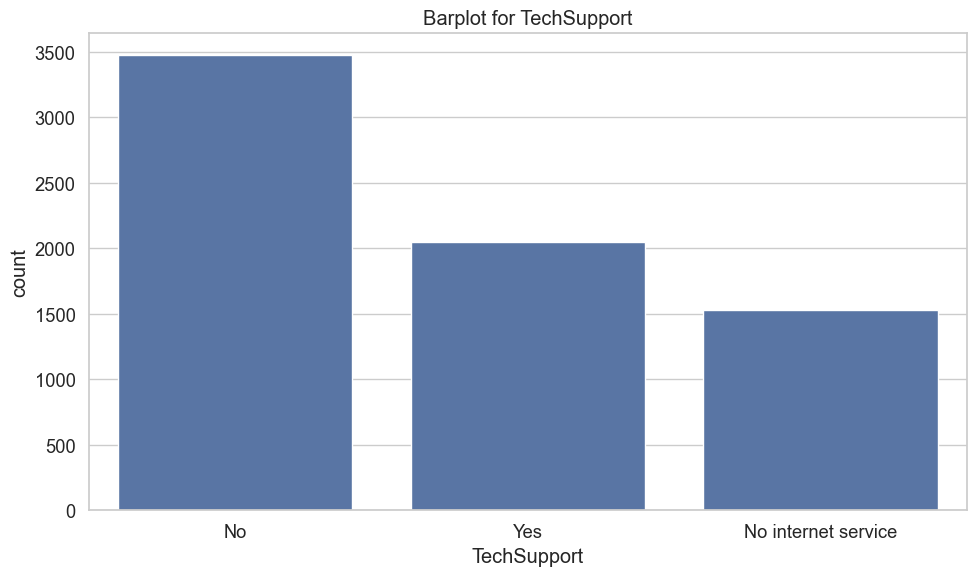

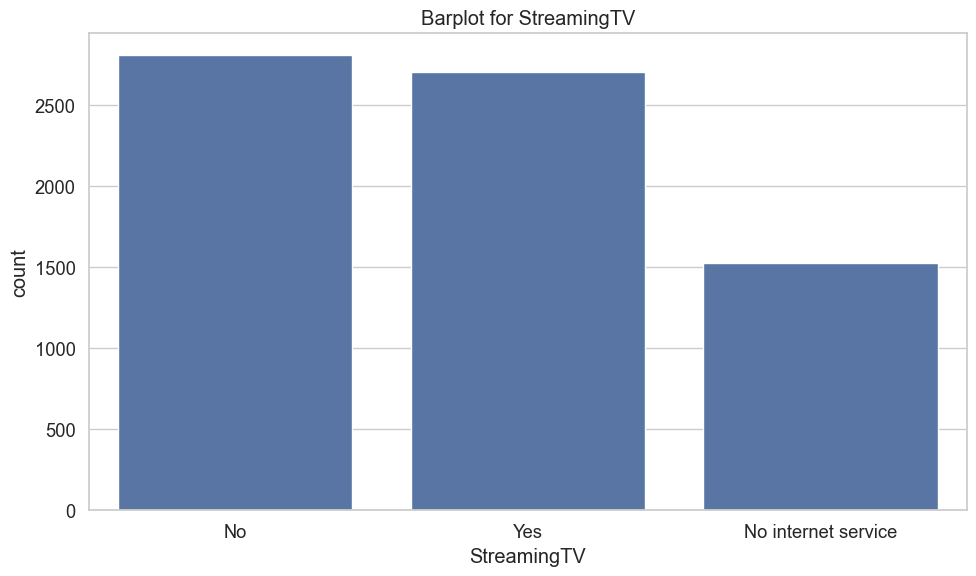

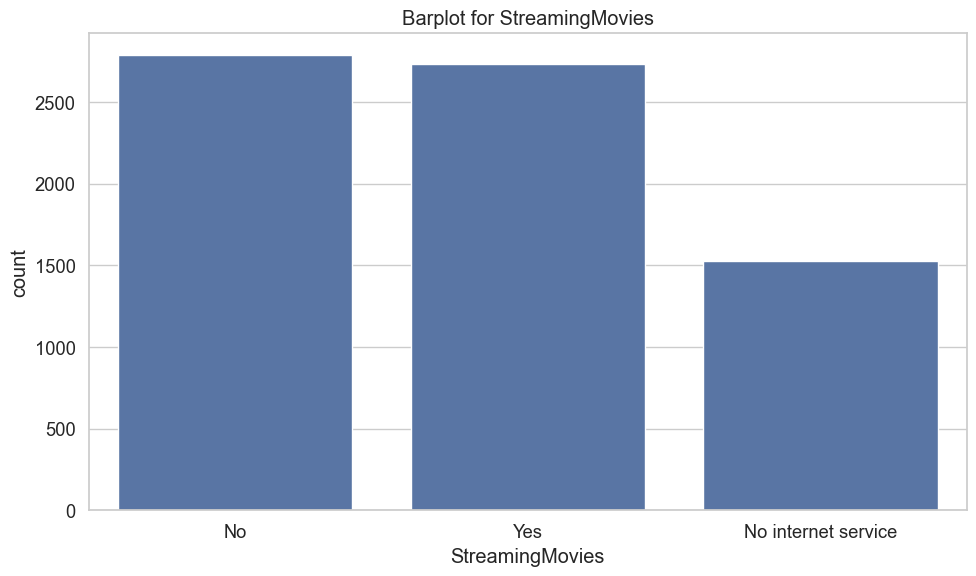

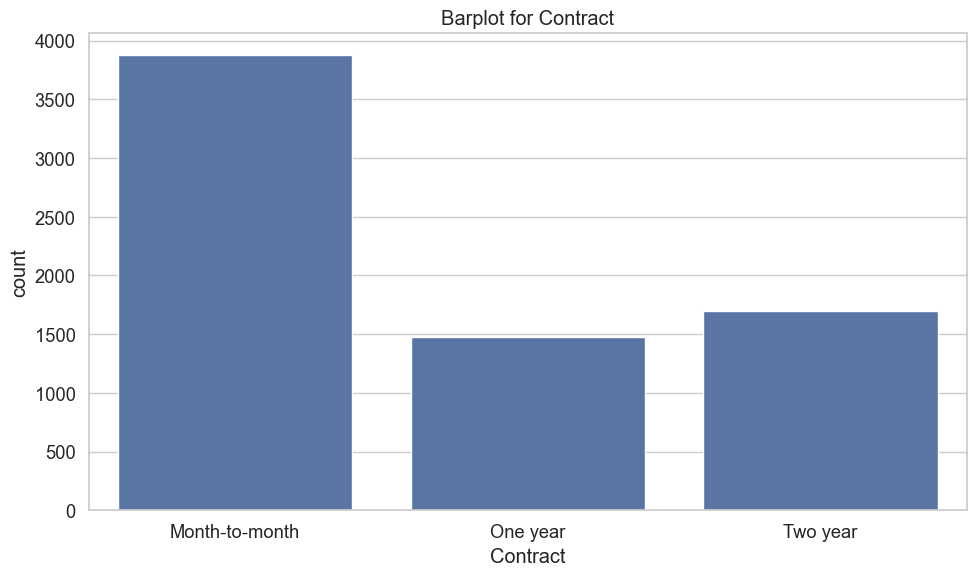

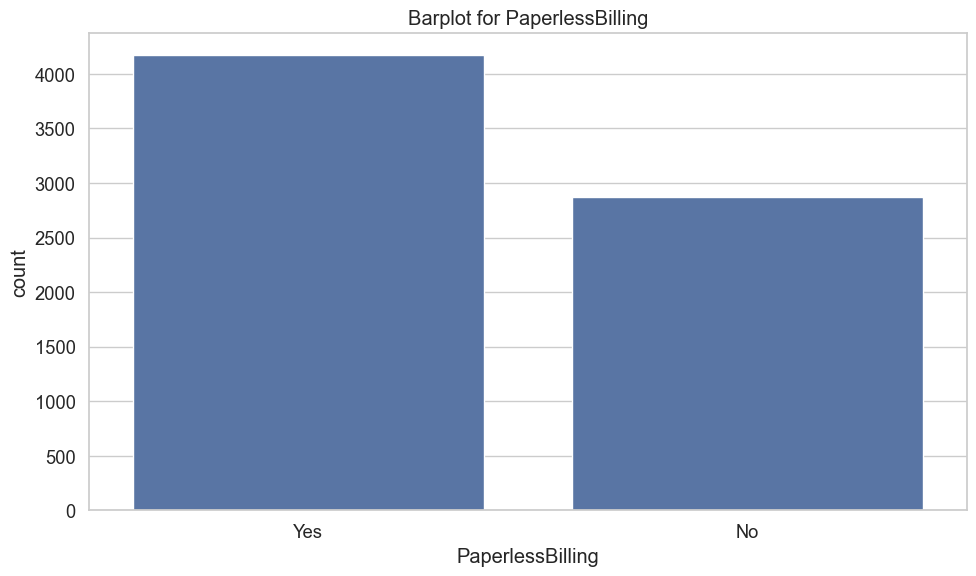

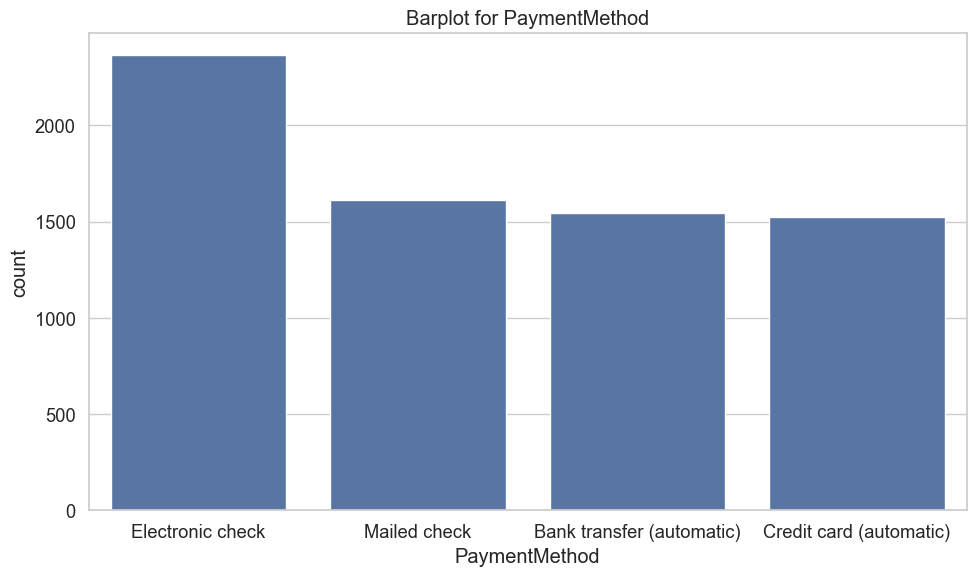

In [15]:
# Visualizing the distributions of categorical columns using barplots
for col in cat_cols:
    sns.countplot(data=df, x=col)
    plt.title(f"Barplot for {col}")
    plt.xticks()
    plt.tight_layout()
    plt.show()

- Now as we can see all the values of the categorical columns are right and there was no mistakes
- Most of the distributions are balanced but wile some are not but it won't make a problem for us

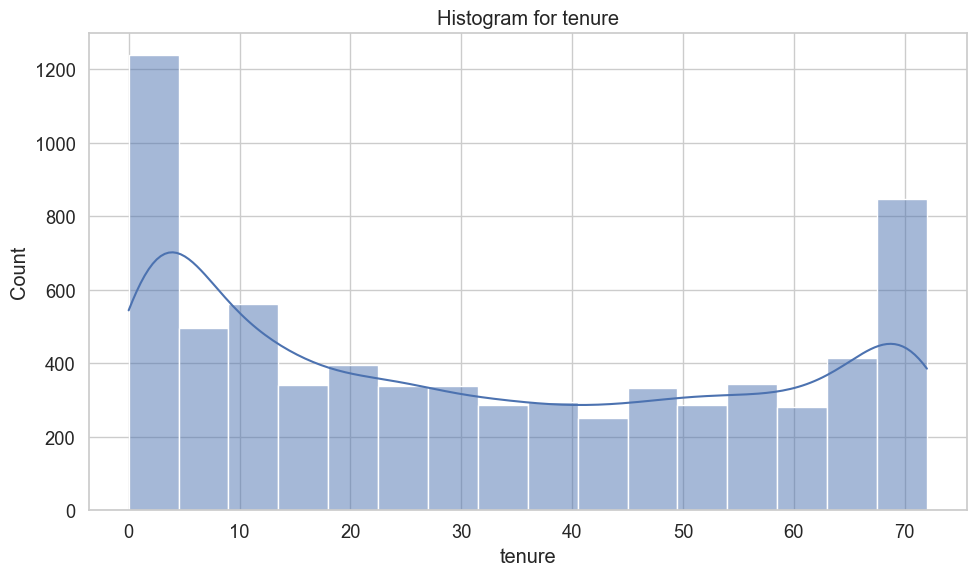

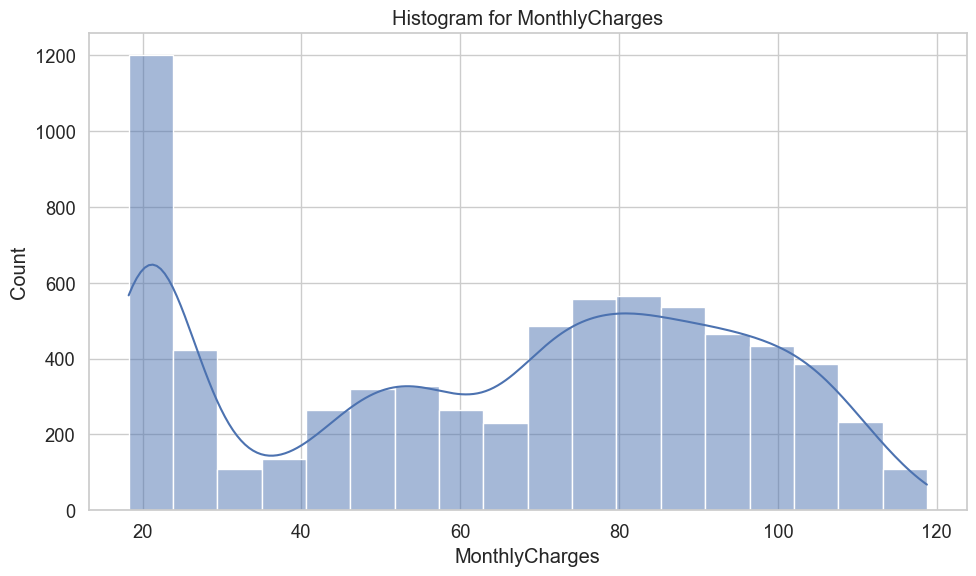

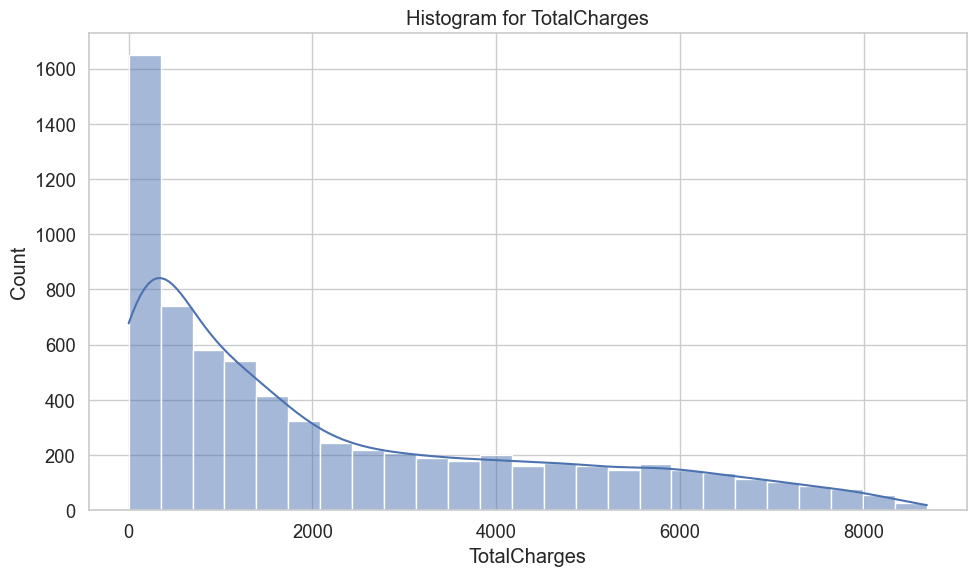

In [16]:
# Visualizing the distribution of the numerical columns using histograms
for col in num_cols:
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Histogram for {col}")
    plt.tight_layout()
    plt.show()

### Target Visualization

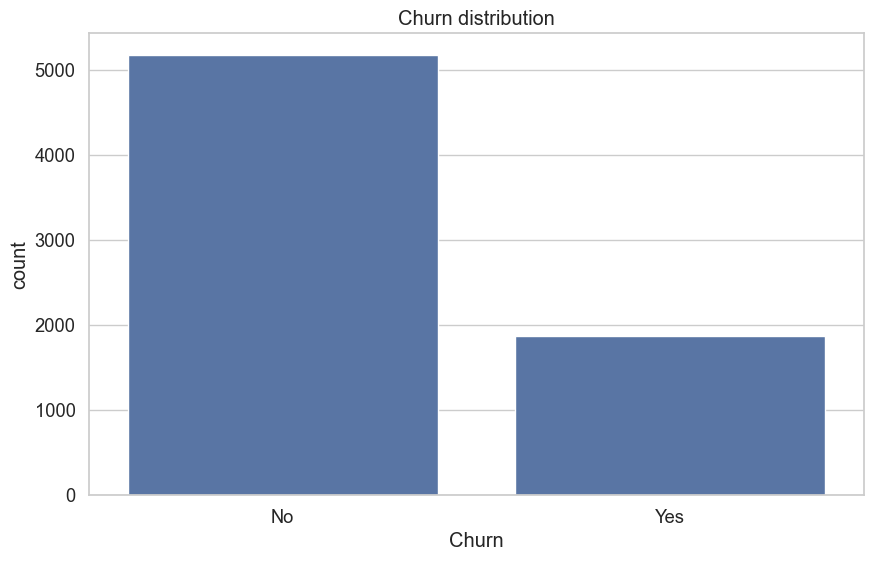

In [17]:
# Visualizing churn distribution
sns.countplot(data=df, x="Churn")
plt.title("Churn distribution")
plt.show()


We can notice here that we have imbalanced classes in our target column `Churn` which matters us the most, so we will balance it using `class_weight='balanced'`

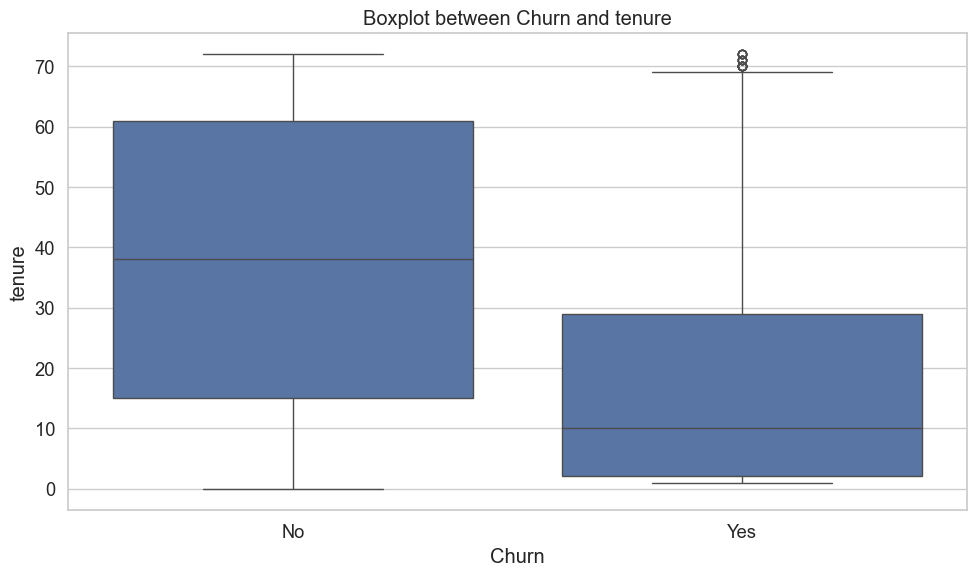

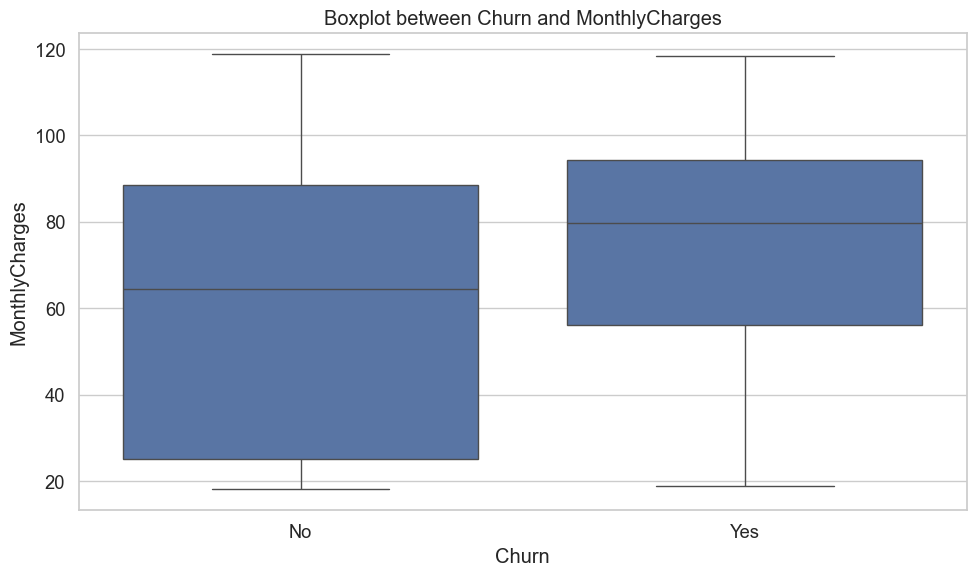

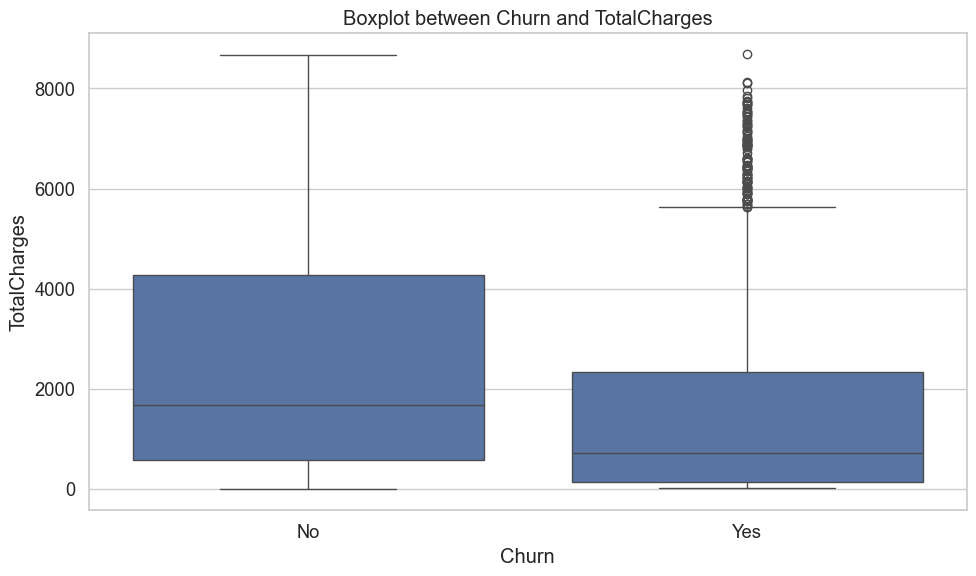

In [18]:
# Visualizing the Distribution Summary of Numerical Features by Churn using boxplots
for col in num_cols:
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(f"Boxplot between Churn and {col}")
    plt.tight_layout()
    plt.show()

From the boxplots, we can observe the following patterns:

1. Customers with low tenure are more likely to churn.
(Newer customers tend to leave the service earlier)
2. Customers with higher monthly charges show a higher churn rate.
(Higher billing may contribute to dissatisfaction)
3. TotalCharges does not provide new information on its own, as it is highly dependent on tenure and monthly charges.
   
Also remember when a customer churns early, both tenure and TotalCharges naturally remain low.

- Now we can visualize it more accurately using histograms

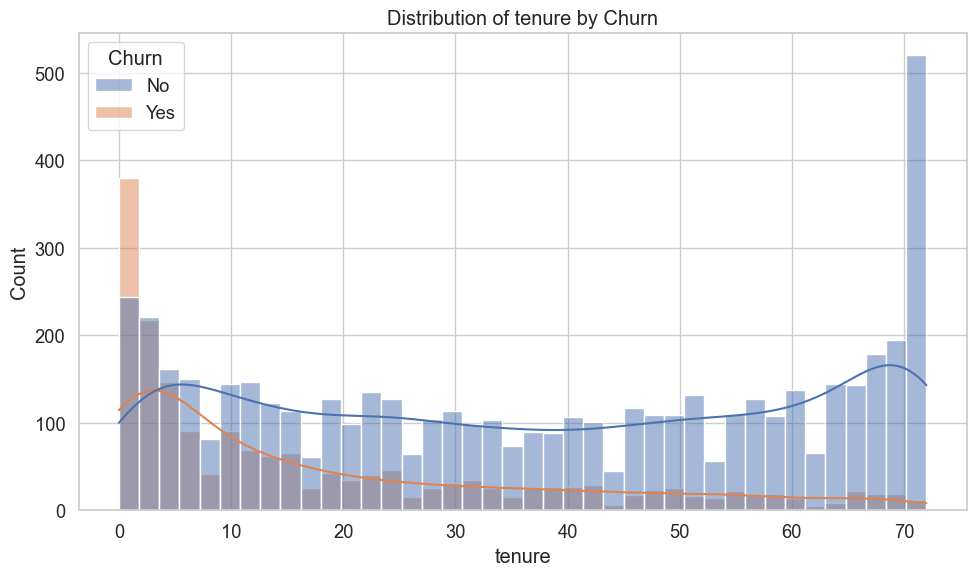

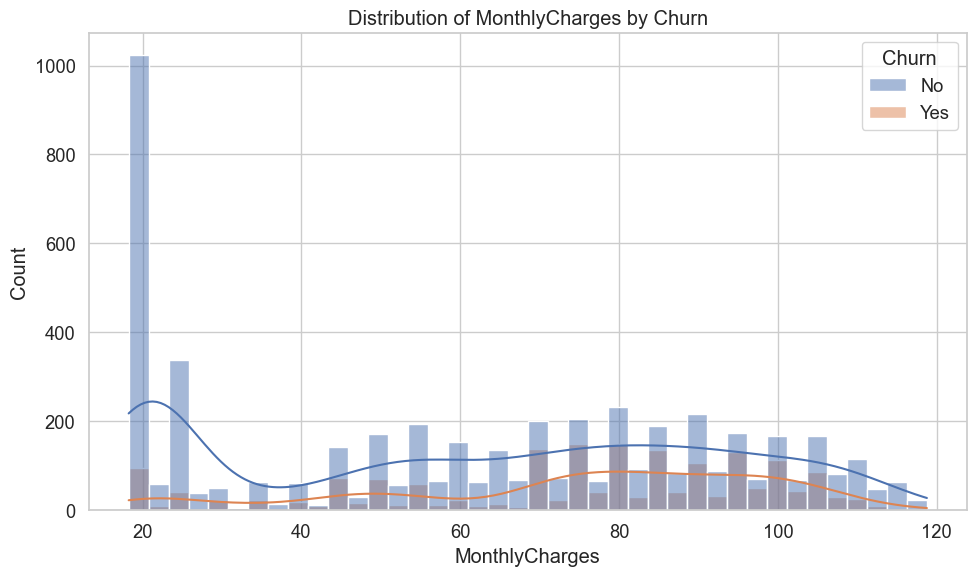

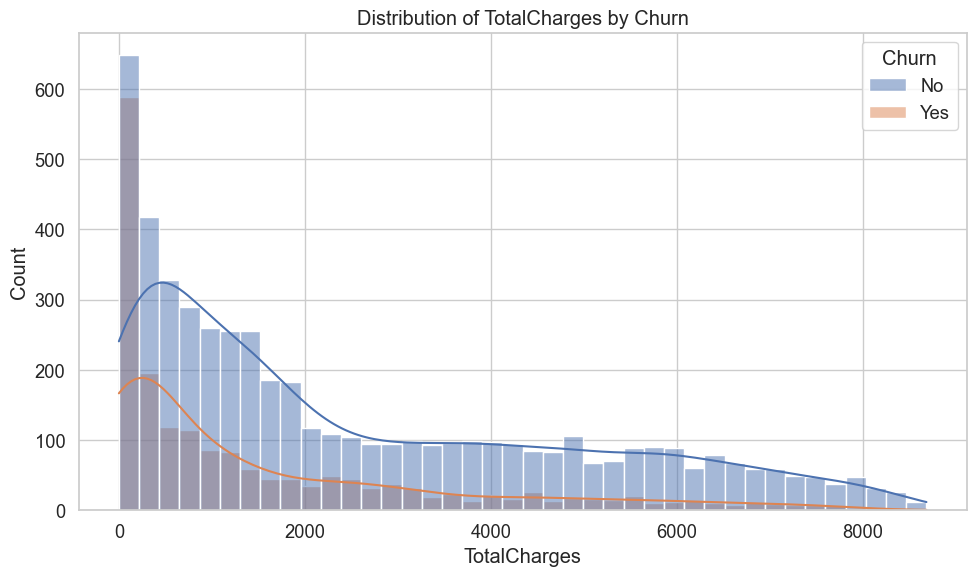

In [19]:
# Visualizing the Distribution of Numerical Features using histograms and churn as the hue
for col in num_cols:
    sns.histplot(
        data=df,
        x=col,
        hue='Churn',
        bins=40,
        kde=True,            
        stat='count',  
        # element='step'      
    )
    plt.title(f'Distribution of {col} by Churn')
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

Now we can take a clear look at their exact distributions as they confirm our initial observations

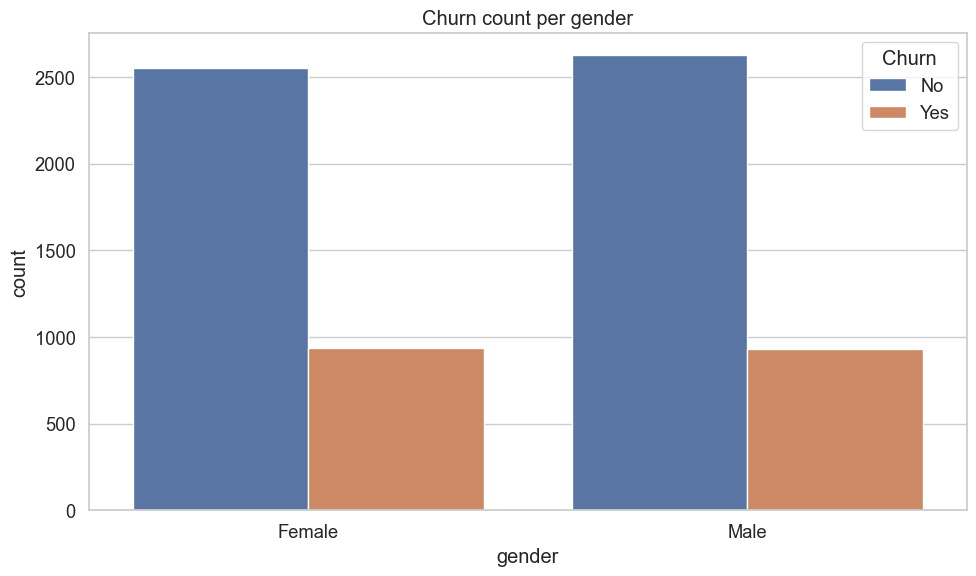

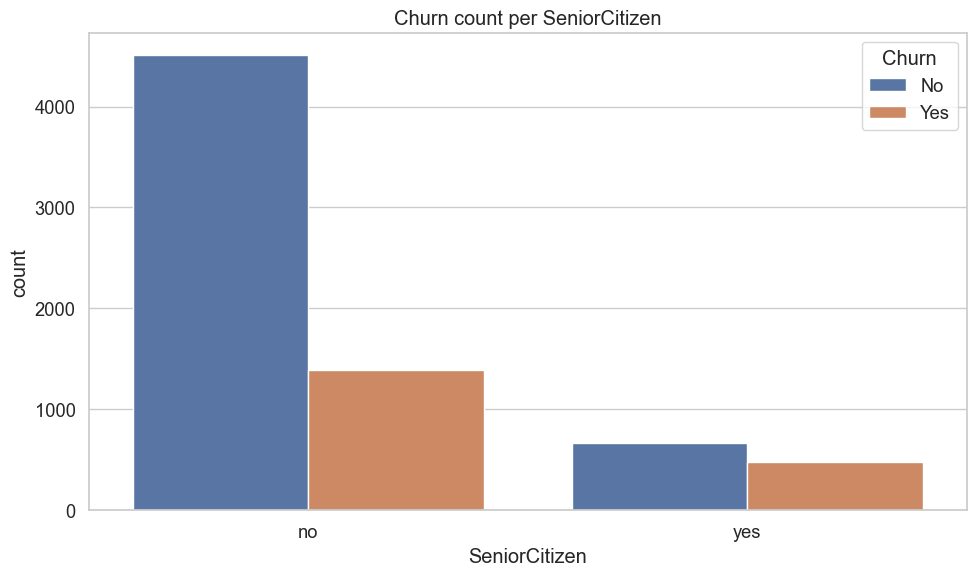

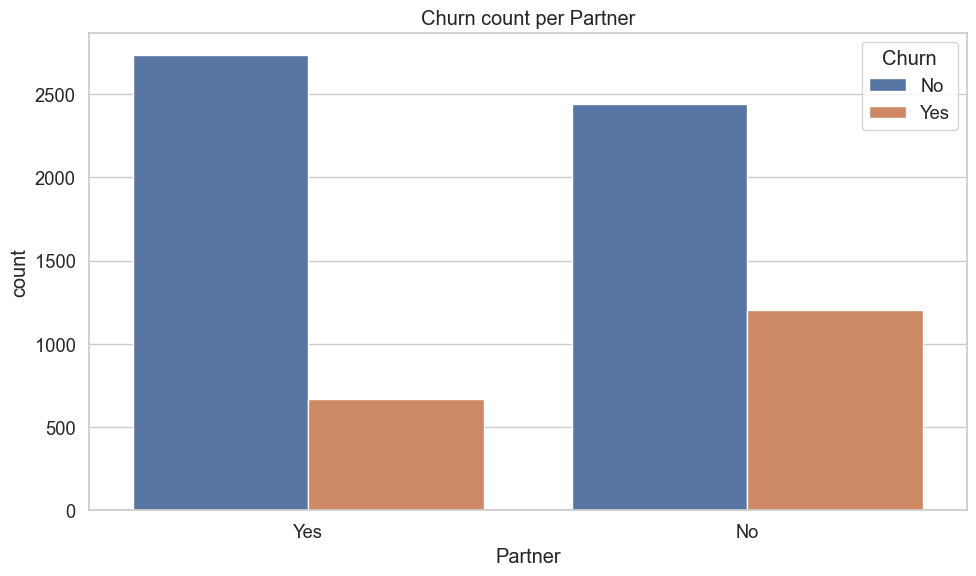

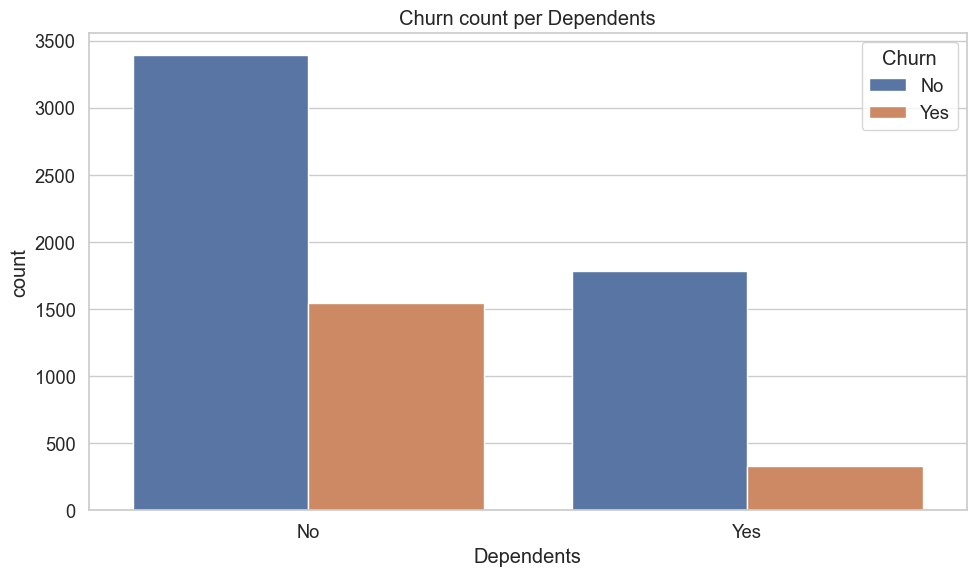

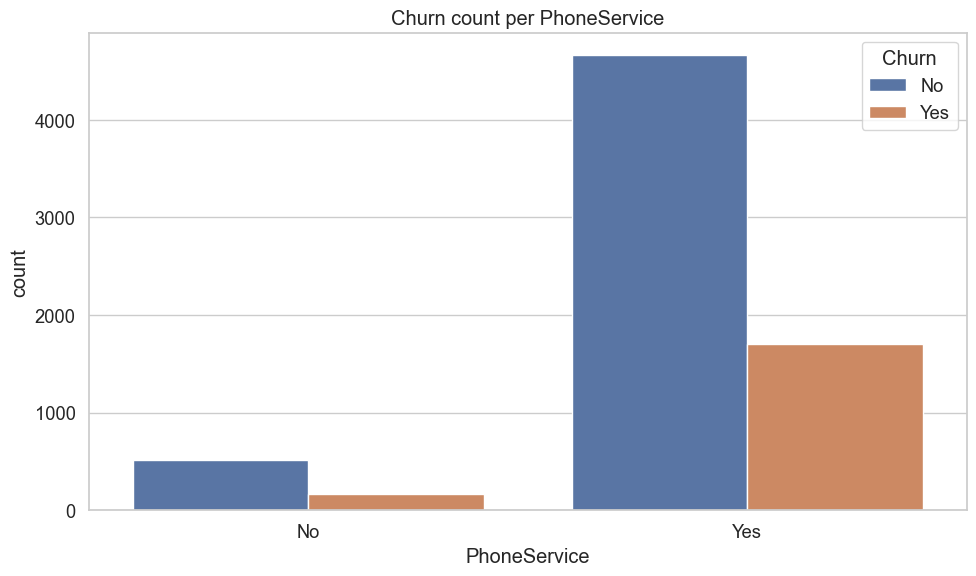

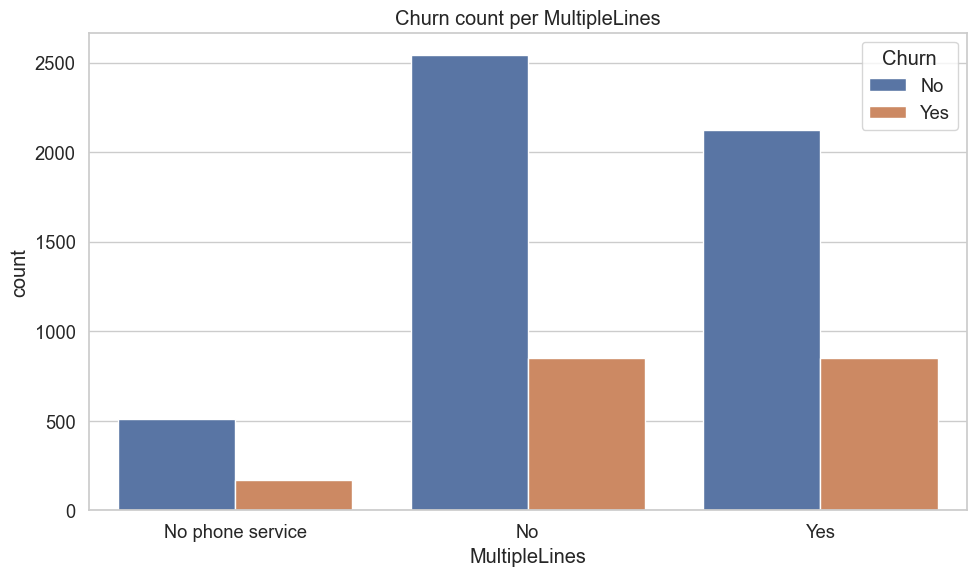

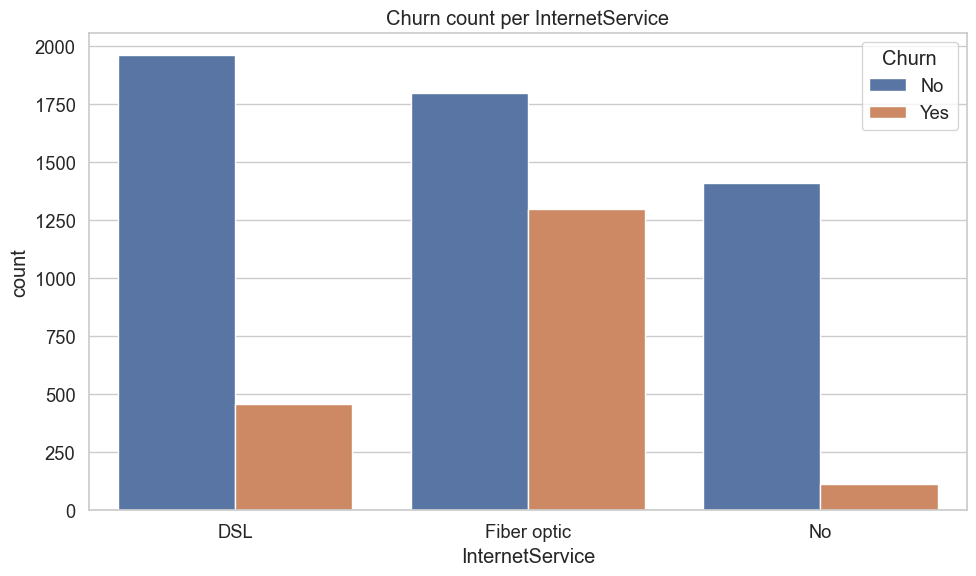

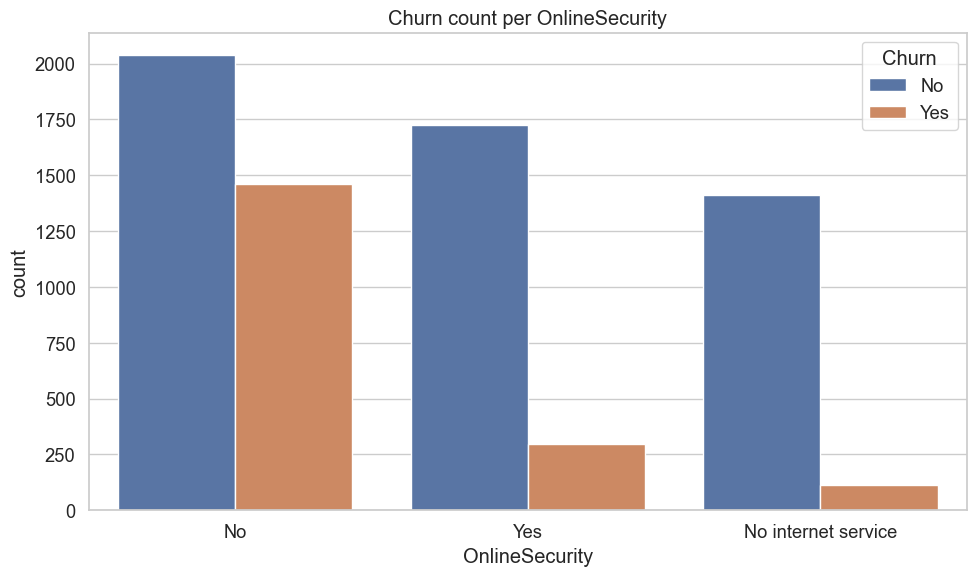

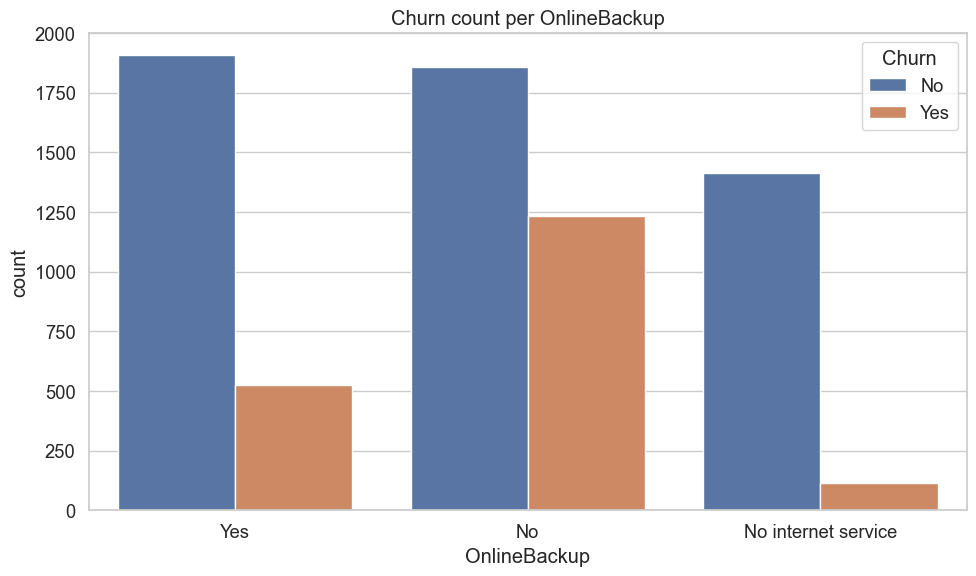

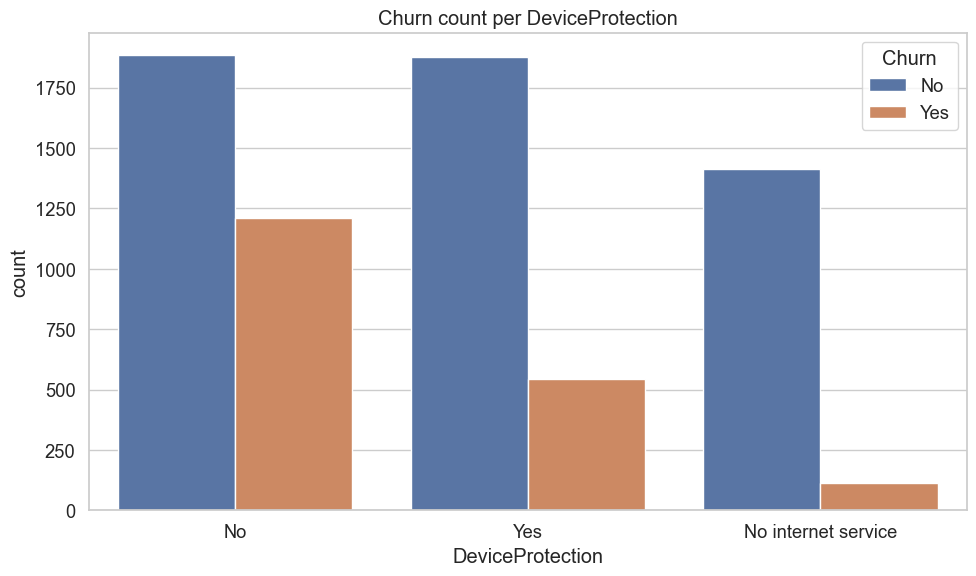

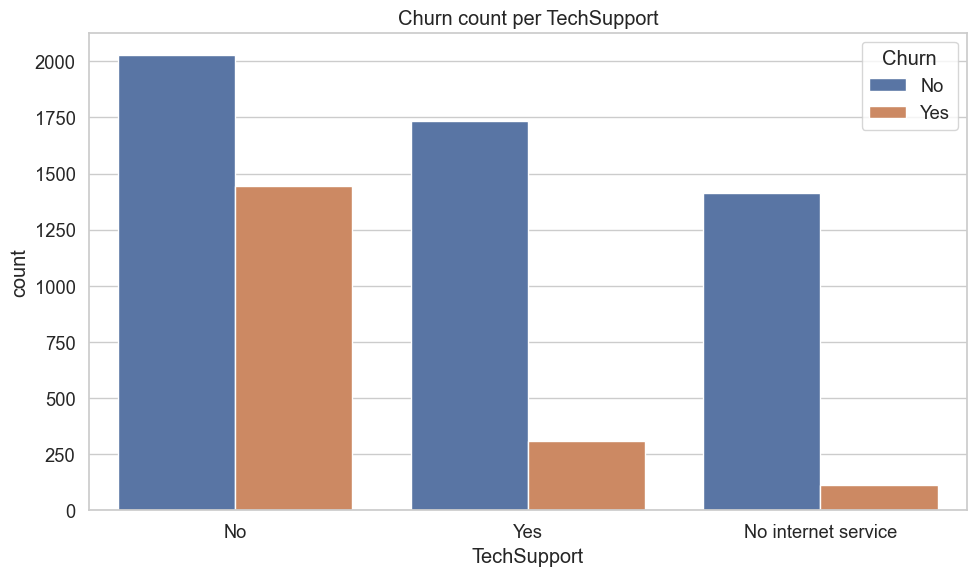

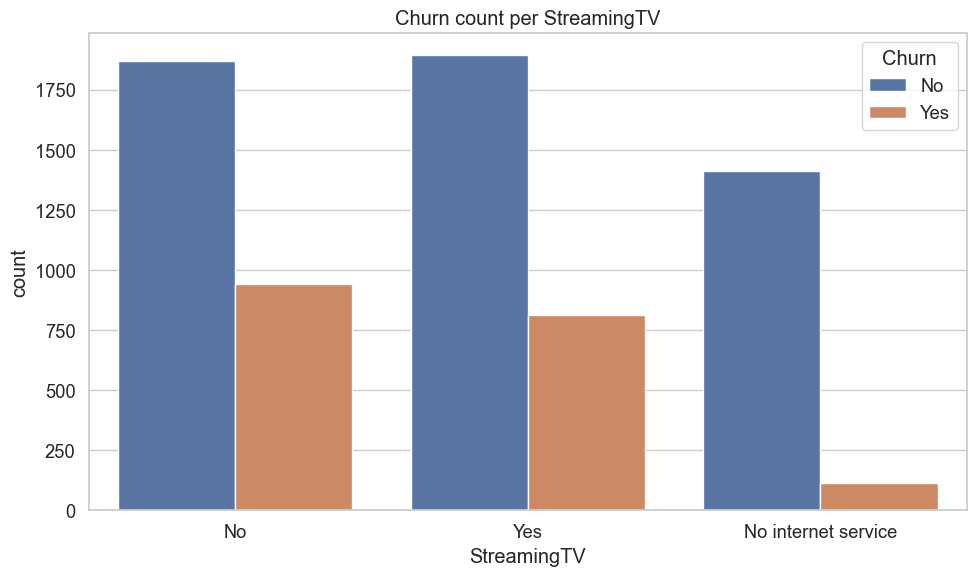

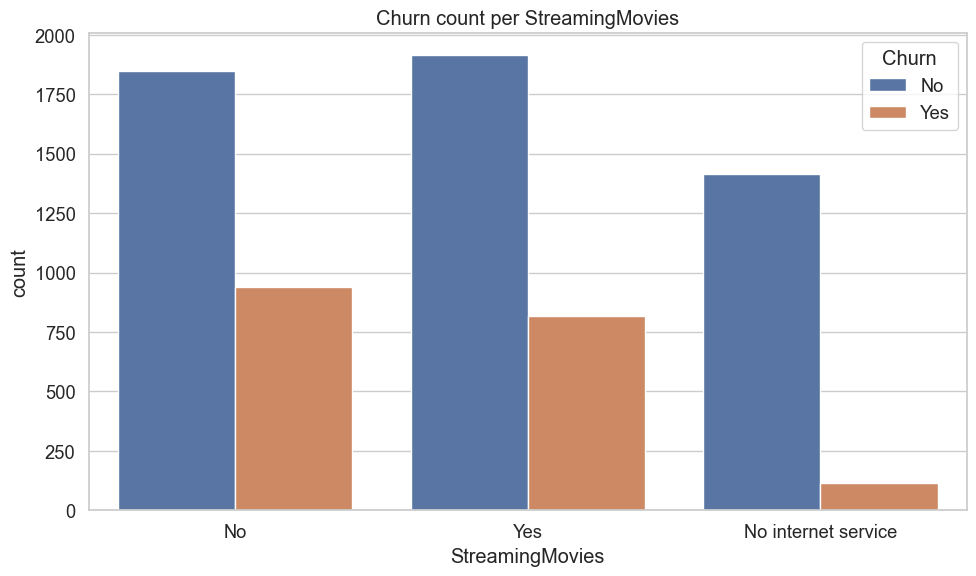

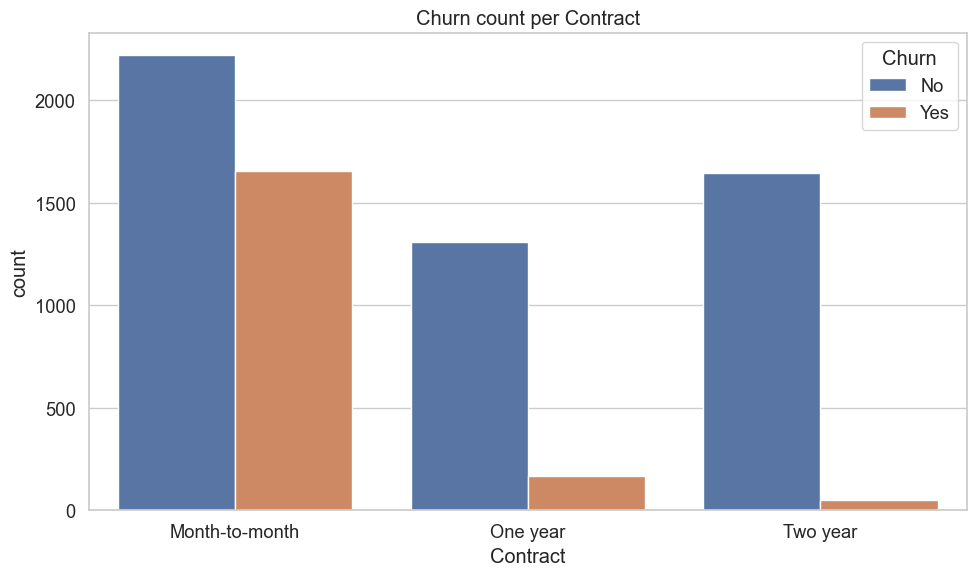

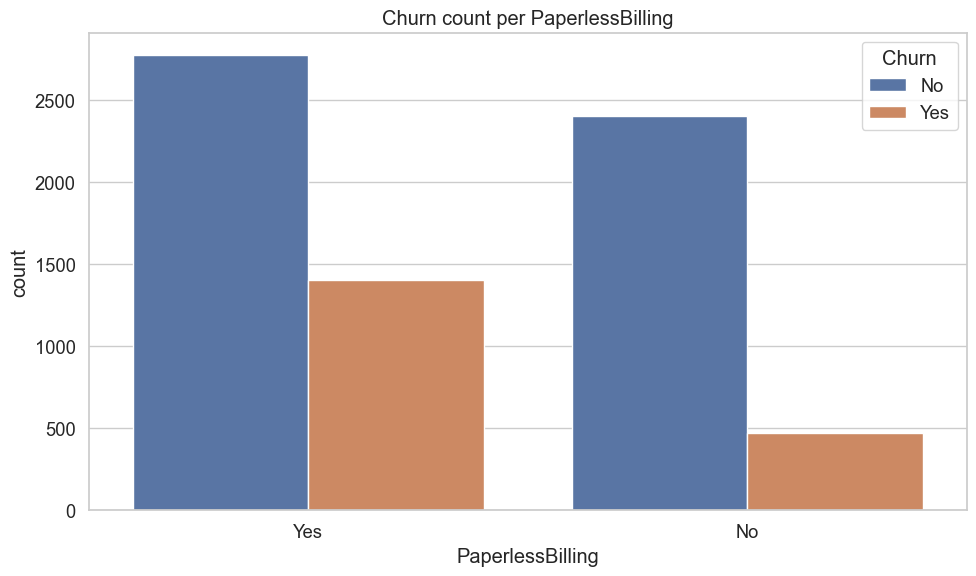

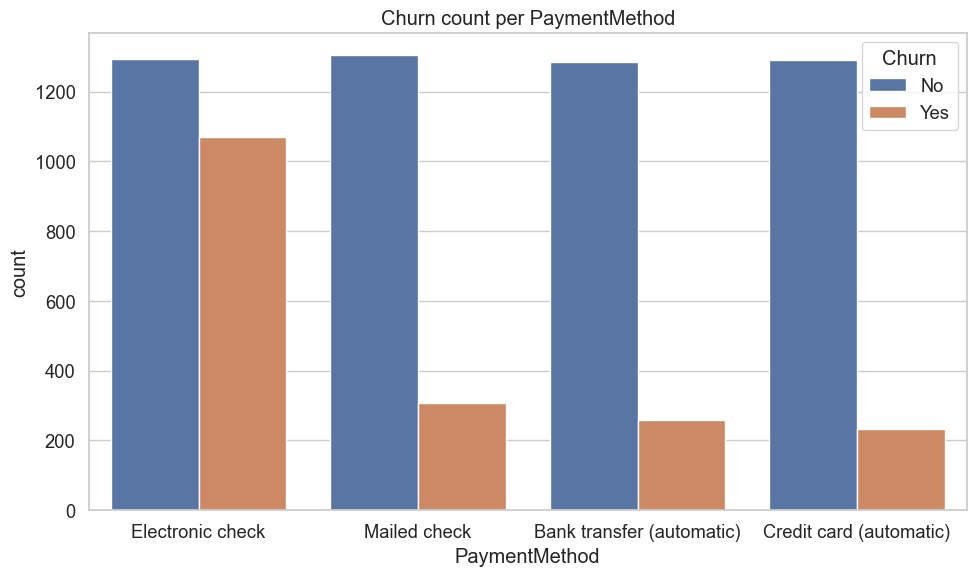

In [20]:
# Visualizing the relation between churn count for each categorial column
for col in cat_cols:
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f"Churn count per {col}")
    plt.tight_layout()
    plt.show()

### Correlation heatmap

Before we do the correlation heat map we need to convert `Churn` to numerical data type so we will map it to 0 and 1

In [21]:
# Converting Churn column to numerical
df['Churn'] = df['Churn'].map({"Yes": 1, "No": 0})

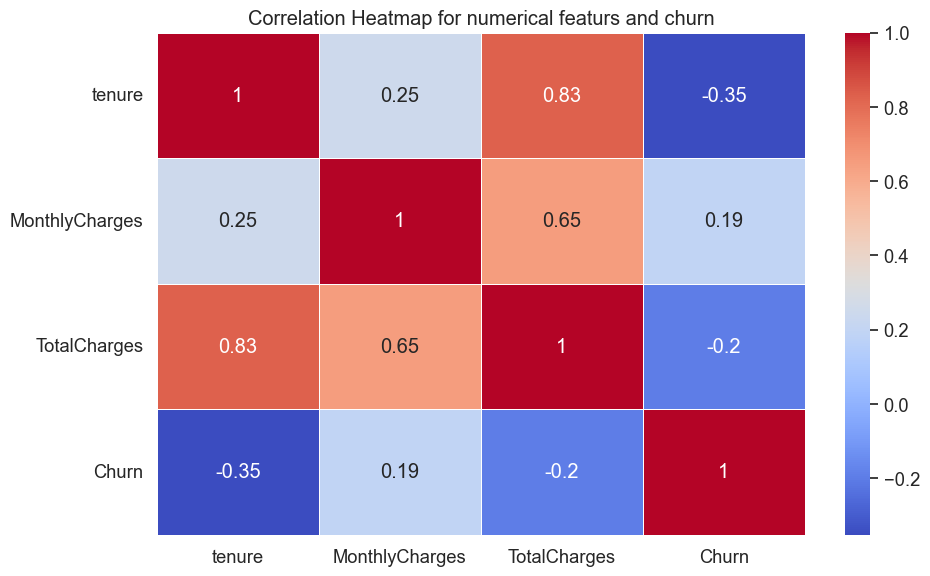

In [22]:
sns.heatmap(
    df[num_cols + ["Churn"]].corr(), 
    annot=True, 
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Heatmap for numerical featurs and churn")
plt.tight_layout()
plt.show()

- There is a high correlation between `TotalCharges` and `tenure`
- `Churn` is correlated the most with `tenure` (Negative correlation means as tenure decreases the churn probability increases)

# Feature Selection

In [23]:
# Separating the encoded dataframe from the original
df_encoded = df.copy()
df_encoded.drop(columns=['customerID'], inplace=True)

- Our target `Churn` values are already mapped to 0 and 1
- We will encode our categorical features using label encoding since the features doesn't include a lot of values
<!-- - The binary featurs will be label encoded
- The non-binary features will be one-hot encoded since they are not ordinal -->

## Data Encoding

In [24]:
# Mapping Churn column ("Yes": 1, "No": 0)
# df_encoded['Churn'] = df_encoded['Churn'].map({"Yes": 1, "No": 0})

In [25]:
# Mapping binary features ("Yes": 1, "No": 0)
binary_cols = ["SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({"Yes": 1, "yes":1, "No": 0, "no": 0})

In [26]:
# Mapping gender column ("Male": 1, "Female": 0)
df_encoded['gender'] = df_encoded['gender'].map({"Male": 1, "Female": 0})

In [27]:
nonbin_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

label_encoder = LabelEncoder()
for col in nonbin_cols:
    df_encoded[col] = label_encoder.fit_transform(df[col])

In [28]:
df_encoded.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2818,1,0,1,1,29,1,0,1,2,0,0,0,2,2,0,0,1,94.65,2649.15,1
4321,0,1,0,0,14,1,2,1,0,0,2,0,0,0,0,1,0,80.35,1058.10,0
814,1,1,0,0,5,1,0,2,1,1,1,1,1,1,0,0,0,20.05,94.15,0
4843,1,0,1,1,69,1,0,2,1,1,1,1,1,1,2,0,0,20.20,1376.50,0
123,0,0,1,1,7,1,0,0,2,0,0,0,0,0,0,0,3,50.70,350.35,0


In [29]:
# Encoding categorical features using one-hot enocding
# nonbin_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]

# df_encoded = pd.get_dummies(df_encoded, columns=nonbin_cols, drop_first=True)
# df_encoded

## Multicolinearity Check

We already know that `Tenure` is highly correlated with`TotalCharges`, so we will check exactly which if they are causing multicolinearity to `Chun` and which will be selected.

We will identify it using VIF Analysis

In [30]:
X = df_encoded[['tenure', 'MonthlyCharges', 'TotalCharges']]
X_const = sm.add_constant(X)

vif = pd.DataFrame()
vif["Feature"] = X_const.columns
vif['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif.sort_values(by='VIF', ascending=False).reset_index()

,index,Feature,VIF
0,0,const,14.899868
1,3,TotalCharges,9.510931
2,1,tenure,5.836728
3,2,MonthlyCharges,3.216730


As we can see `TotalCharges` and `tenure` has high VIF values (Over 5) and that is so logical since `TotalCharges` is the product of the other two columns.

Now we will remove `TotalCharges` since it is the heighest and the VIF score must be lower for the rest of the columns

In [31]:
X = df_encoded[['tenure', 'TotalCharges']]
X_const = sm.add_constant(X)

vif = pd.DataFrame()
vif["Feature"] = X_const.columns
vif['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif.sort_values(by='VIF', ascending=False).reset_index()

,index,Feature,VIF
0,1,tenure,3.150308
1,2,TotalCharges,3.150308
2,0,const,2.759397


Now all the VIF Scores are low so the numerical features we will take are `TotalCharges` and `tenure`

since we will mostly use tree based models it is not nesessary to remove the high VIF features but since `TotalCharges` and `tenure` are almost redundant so it is better to remove it

In [32]:
df_encoded.drop(columns=['TotalCharges'], inplace=True)

## Chi-squared test

In [33]:
X = df_encoded[cat_cols]
y = df_encoded['Churn']

chi_scores, p_values = chi2(X,y)

chi2_results = pd.DataFrame({
    'Feature': cat_cols,
    'Chi2 Score': chi_scores,
    'p-value': p_values
}).sort_values(by="Chi2 Score", ascending=False).reset_index()

chi2_results

,index,Feature,Chi2 Score,p-value
0,13,Contract,1115.780167,1.227941e-244
1,7,OnlineSecurity,551.611529,5.615882e-122
2,10,TechSupport,523.303866,8.086236e-116
3,8,OnlineBackup,230.086520,5.707869e-52
4,9,DeviceProtection,191.303140,1.651539e-43
5,1,SeniorCitizen,134.351545,4.576959e-31
6,3,Dependents,133.036443,8.876729e-31
7,14,PaperlessBilling,105.680863,8.661987e-25
8,2,Partner,82.412083,1.104764e-19
9,15,PaymentMethod,58.492250,2.040933e-14


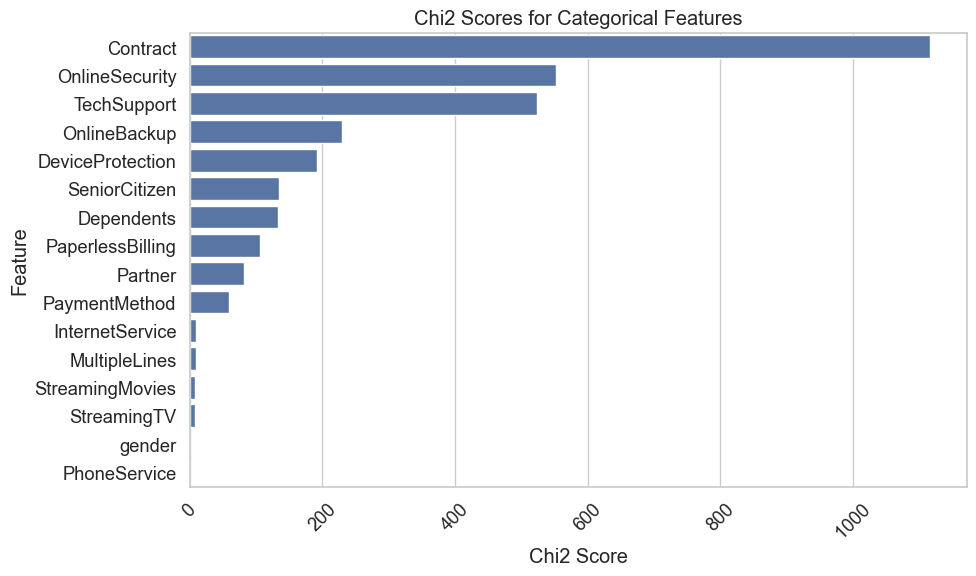

In [34]:
plt.figure(figsize=(10,6))
sns.barplot(data=chi2_results, x='Chi2 Score', y='Feature')
plt.xlabel('Chi2 Score')
plt.title('Chi2 Scores for Categorical Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can notice that `gender` and `PhoneService` have the lowest Chi2 score and the heighst p-value, which means they are the least affecting so we can remove them.

Although there are many features with low Chi2 score but the low p-values means they may have a some relation with the target.

In [35]:
df_encoded.drop(columns=['gender', 'PhoneService'], inplace=True)

# Train Test Split

### Splitting the Data
We split our dataset into **Training** (80%) and **Test** (20%) sets. The model learns from the training data and is evaluated on the unseen test data.

In [36]:
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify=y)

## Feature Scaling

We will scale the numerical features using standard scaler through column transforme to avoid data leakage

In [37]:
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), ['tenure', 'MonthlyCharges'])],remainder='passthrough')

# Modeling

Here we will train and compare between Linear Regression, KNN, random forest, xgboost, and light gbm

First We will create an evaluation function to evaluate each model

In [38]:

# Comprehensive evaluation
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):

    
    # Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Computing Metrics
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    train_auc = roc_auc_score(y_train, y_train_proba)
    test_auc = roc_auc_score(y_test, y_test_proba)
    
    
    # ----------------------------------------------------
    # Metrics Display
    # ----------------------------------------------------
    
    print(f"\n====================== {model_name} EVALUATION ======================")
    
    # Classification Report
    print("\nClassification Report (Test Data)")
    print(classification_report(y_test, y_test_pred))

    # Accuracy & AUC summary
    print(f"| {'Metric':<10} | {'Training Set':<15} | {'Testing Set':<15} |")
    print("-" * 47)
    print(f"| {'Accuracy':<10} | {train_accuracy:.4f}{'':<13} | {test_accuracy:.4f}{'':<13} |")
    print(f"| {'F1 Score':<10} | {train_f1:.4f}{'':<13} | {test_f1:.4f}{'':<13} |")
    print(f"| {'AUC-ROC':<10} | {train_auc:.4f}{'':<13} | {test_auc:.4f}{'':<13} |")

    
    # ----------------------------------------------------
    # Plots
    # ----------------------------------------------------
    
    # 1. Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Churn (0)', 'Churn (1)'], 
                yticklabels=['No Churn (0)', 'Churn (1)'])
    plt.title(f'Confusion Matrix - {model_name} (Test Data)')
    plt.xlabel('Predictions')
    plt.ylabel('Exact Values')
    plt.show()
    

    # 2. Bar Plot for Accuracies 
    accuracies = [train_accuracy, test_accuracy]
    labels = ['Training Accuracy', 'Testing Accuracy']
    ax = sns.barplot(x=labels, y=accuracies, palette=['skyblue', 'lightcoral'])
    plt.title(f'Train and Test Accuracies comparison - {model_name}')
    plt.ylim(0.5, 1.1)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f')
    plt.show()
    

    # 3. AUC-ROC Curve Plot 
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
    
    plt.plot(fpr_test, tpr_test, label=f'Test AUC = {test_auc:.4f}', color='red')
    plt.plot(fpr_train, tpr_train, label=f'Train AUC = {train_auc:.4f}', color='blue')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance (0.5)')
    plt.title(f'AUC-ROC Curve - {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    
    
    # Returning the results as a dataframe
    metrics_df = pd.DataFrame({
        'Model': [model_name],
        'Train Accuracy': [train_accuracy],
        'Test Accuracy': [test_accuracy],
        'Test F1 Score': [test_f1],
        'Test AUC-ROC': [test_auc],
        'Test Recall (Churn)': [classification_report(y_test, y_test_pred, output_dict=True)['1']['recall']]
    })
    
    return metrics_df

# Model Selection and Tuning Strategy

To find the best performing model, we follow a two-stage approach:

1.  **Baseline Testing**: We evaluate several classifiers (Random Forest, KNN, XGBoost, LightGBM) with default parameters to establish a performance baseline.
2.  **Hyperparameter Tuning**: The top-performing models are selected for optimization. We use `RandomizedSearchCV` for a broad search of the parameter space, followed by `GridSearchCV` for fine-tuning.

We evaluate models based on **AUC (Area Under Curve)**, **Recall**, and **F1-Score**, as identifying churners is the primary goal.


## Baseline Modeling
We start by training several standard models with their default settings. This gives us a benchmark performance to improve upon.

**Models to test:**
- Random Forest
- K-Nearest Neighbors (KNN)
- XGBoost
- LightGBM

## Baseline Models

- Here we will start to test baseline models with thier default hyperparameters to choose which ones are the best
- We will train them using `sklearn.pipeline` to avoid any data leakage

### 1. Logestic Regression

In [39]:
logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor), ('model', LogisticRegression(random_state=42,max_iter=1000,class_weight='balanced' ))
])

logreg_pipeline.fit(X_train, y_train)

c:\Users\Youssif\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['tenure',
                                                   'MonthlyCharges'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])


====================== Logestic Regression (Baseline) EVALUATION ======================

Classification Report (Test Data)
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409

| Metric     | Training Set    | Testing Set     |
-----------------------------------------------
| Accuracy   | 0.7433              | 0.7310              |
| F1 Score   | 0.6203              | 0.6105              |
| AUC-ROC    | 0.8432              | 0.8326              |


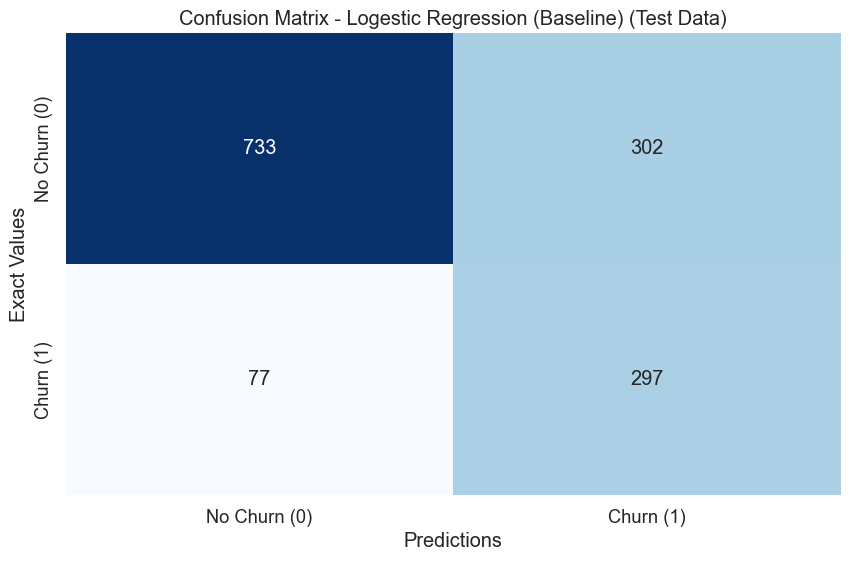

C:\Users\Youssif\AppData\Local\Temp\ipykernel_21324\2738180666.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=accuracies, palette=['skyblue', 'lightcoral'])


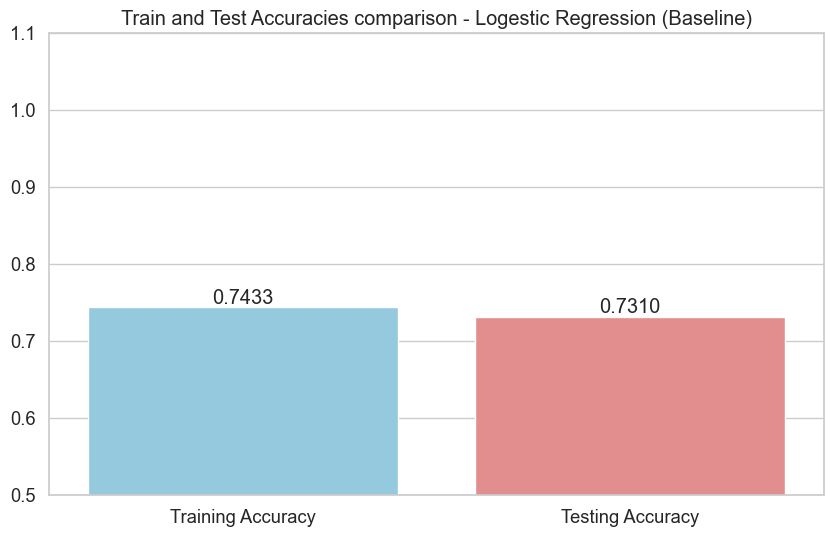

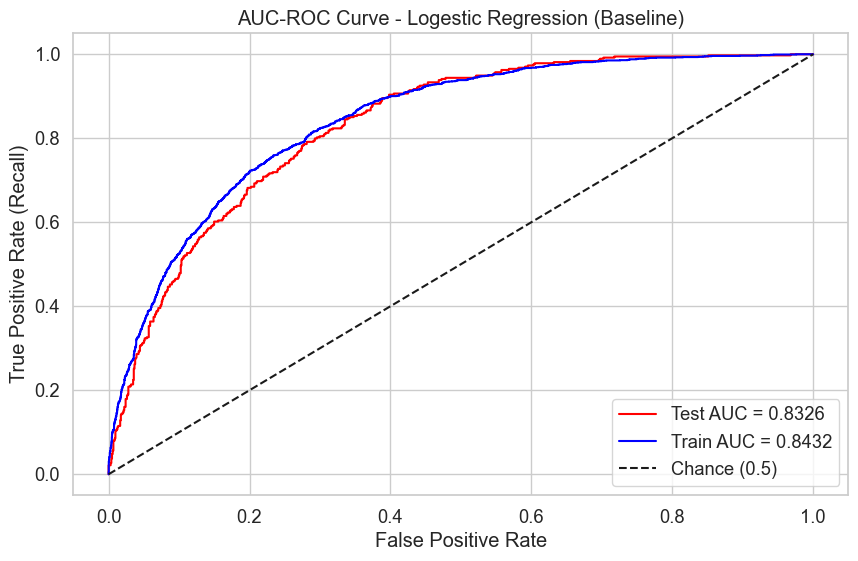

In [40]:
# Logestic Regression Evaluation
logreg_results = evaluate_model(logreg_pipeline, X_train, y_train, X_test, y_test, "Logestic Regression (Baseline)")

### Notes:
- The accuracy and recall may be low which is what we care the most about in this case
- there is no over fitting
- there is underfitting since both the training and test accuracies are low

### 2. Random Forest

In [41]:

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor), ('model', RandomForestClassifier(random_state=42, class_weight="balanced"))
])

rf_pipeline.fit(X_train, y_train)

c:\Users\Youssif\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['tenure',
                                                   'MonthlyCharges'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])


====================== Random Forest (base model) EVALUATION ======================

Classification Report (Test Data)
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1035
           1       0.59      0.47      0.52       374

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409

| Metric     | Training Set    | Testing Set     |
-----------------------------------------------
| Accuracy   | 0.9970              | 0.7715              |
| F1 Score   | 0.9943              | 0.5223              |
| AUC-ROC    | 0.9996              | 0.8149              |


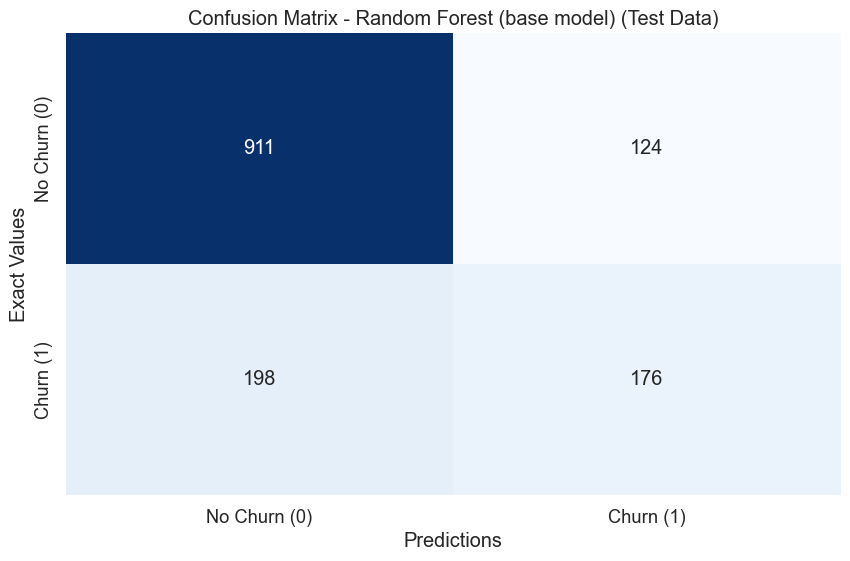

C:\Users\Youssif\AppData\Local\Temp\ipykernel_21324\2738180666.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=accuracies, palette=['skyblue', 'lightcoral'])


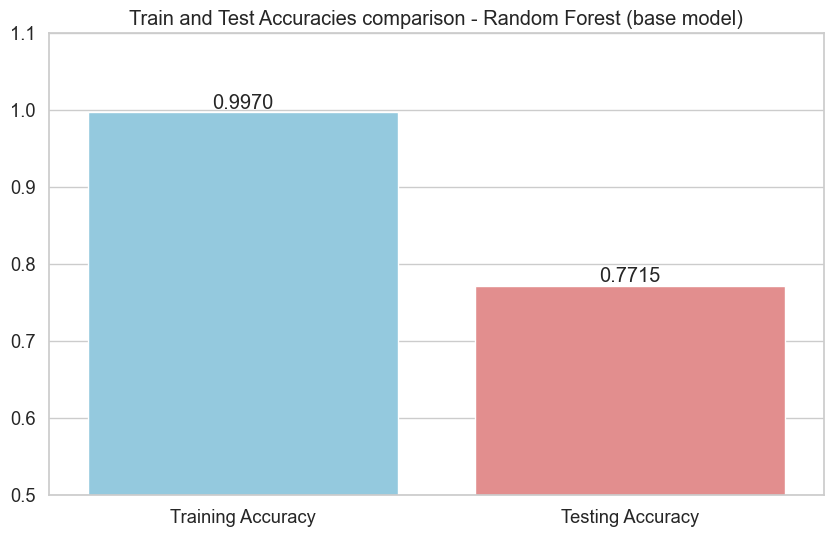

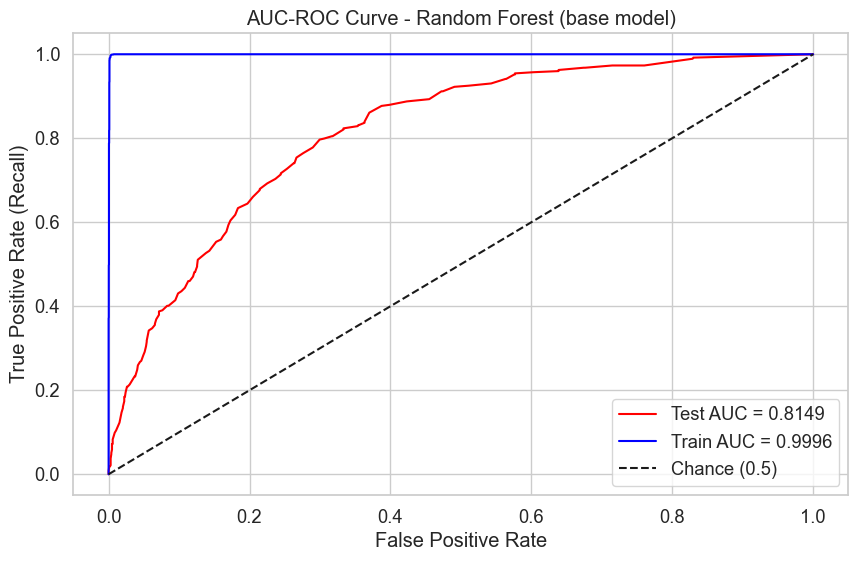

In [42]:
rf_results = evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test, "Random Forest (base model)")

### Notes:
- We can clearly see there is overfitting since the training accuracy and AUC-ROC score are much higher than the test accuracy and AUC-ROC score

### 3. KNN Classifier

In [43]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor), ('model', KNeighborsClassifier(weights='distance'))
])

knn_pipeline.fit(X_train, y_train)

c:\Users\Youssif\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['tenure',
                                                   'MonthlyCharges'])])),
                ('model', KNeighborsClassifier(weights='distance'))])


====================== KNN (base model) EVALUATION ======================

Classification Report (Test Data)
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1035
           1       0.52      0.50      0.51       374

    accuracy                           0.75      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.75      0.74      1409

| Metric     | Training Set    | Testing Set     |
-----------------------------------------------
| Accuracy   | 0.9972              | 0.7452              |
| F1 Score   | 0.9946              | 0.5102              |
| AUC-ROC    | 1.0000              | 0.7512              |


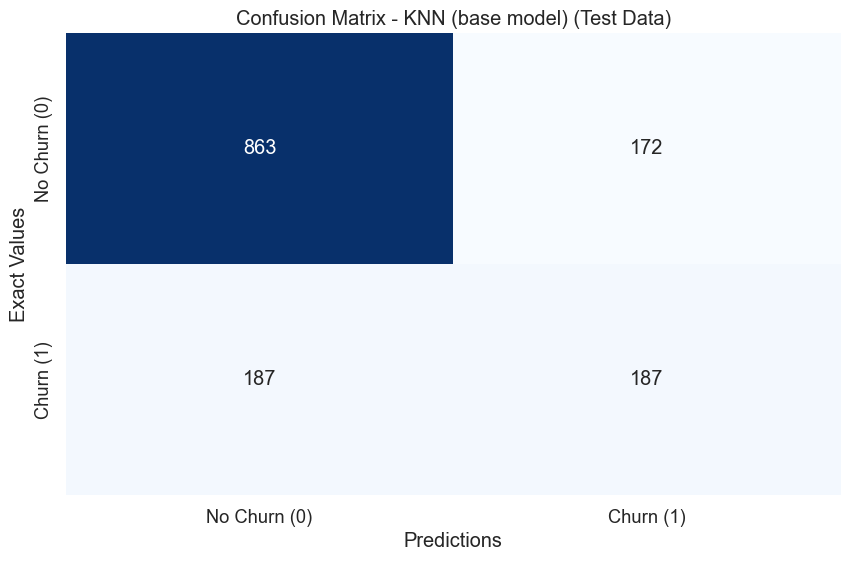

C:\Users\Youssif\AppData\Local\Temp\ipykernel_21324\2738180666.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=accuracies, palette=['skyblue', 'lightcoral'])


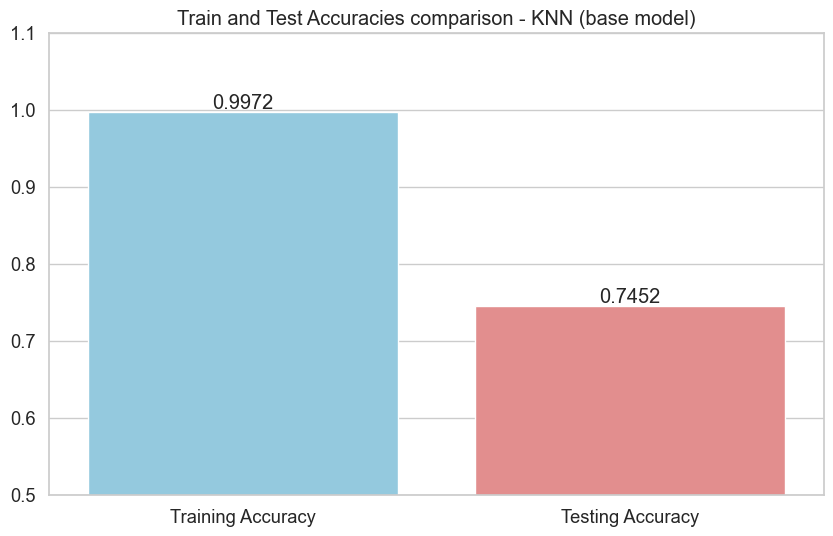

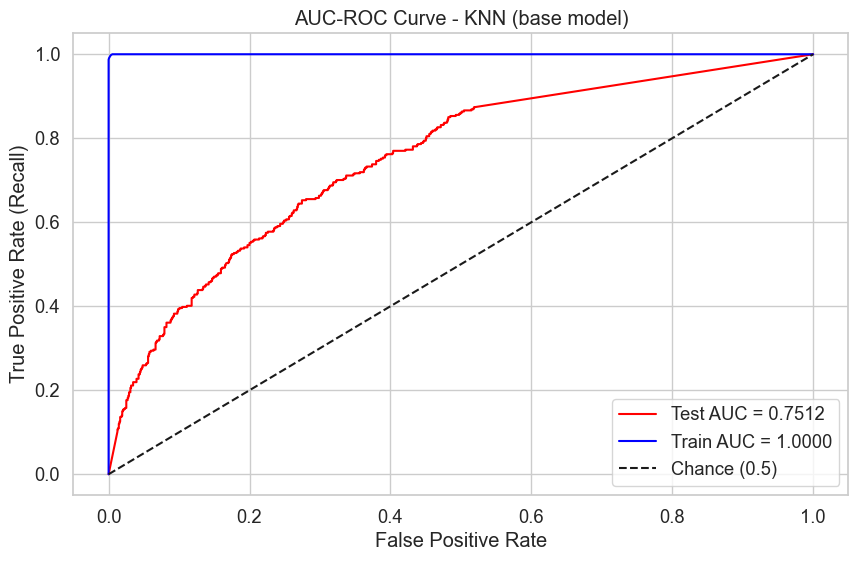

In [44]:
knn_results = evaluate_model(knn_pipeline, X_train, y_train, X_test, y_test, "KNN (base model)")

We can also notice here that the that there is extremely high overfitting

### 4. XGBoost

In [45]:
count_no_churn = y_train.value_counts()[0]
count_churn = y_train.value_counts()[1]

scale_pos_weight_value = count_no_churn / count_churn
print(f"Churn distribution ratio: {scale_pos_weight_value:.2f}")

Churn distribution ratio: 2.77


In [46]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', XGBClassifier(random_state=42,use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight_value))
])

xgb_pipeline.fit(X_train, y_train)

c:\Users\Youssif\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['tenure',
                                                   'MonthlyCharges'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_met...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])


====================== XGBoost EVALUATION ======================

Classification Report (Test Data)
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409

| Metric     | Training Set    | Testing Set     |
-----------------------------------------------
| Accuracy   | 0.9215              | 0.7594              |
| F1 Score   | 0.8703              | 0.6054              |
| AUC-ROC    | 0.9836              | 0.8140              |


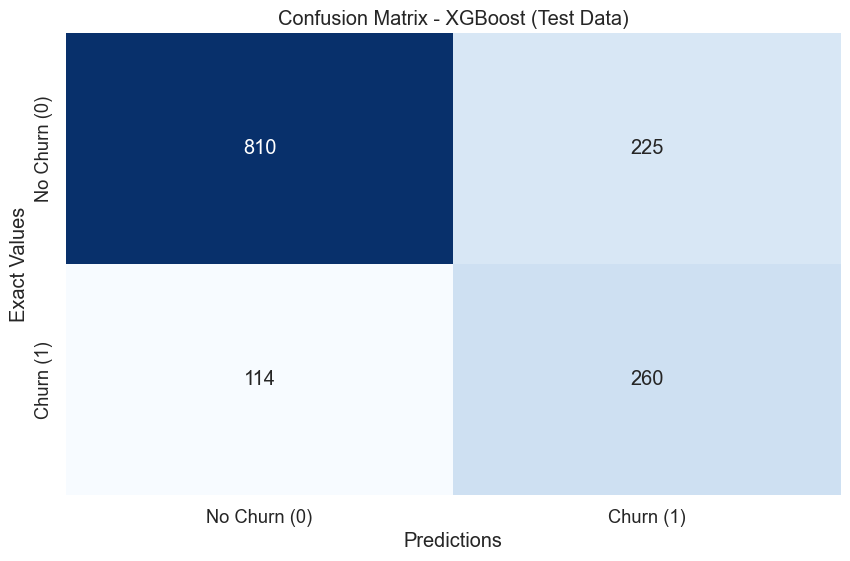

C:\Users\Youssif\AppData\Local\Temp\ipykernel_21324\2738180666.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=accuracies, palette=['skyblue', 'lightcoral'])


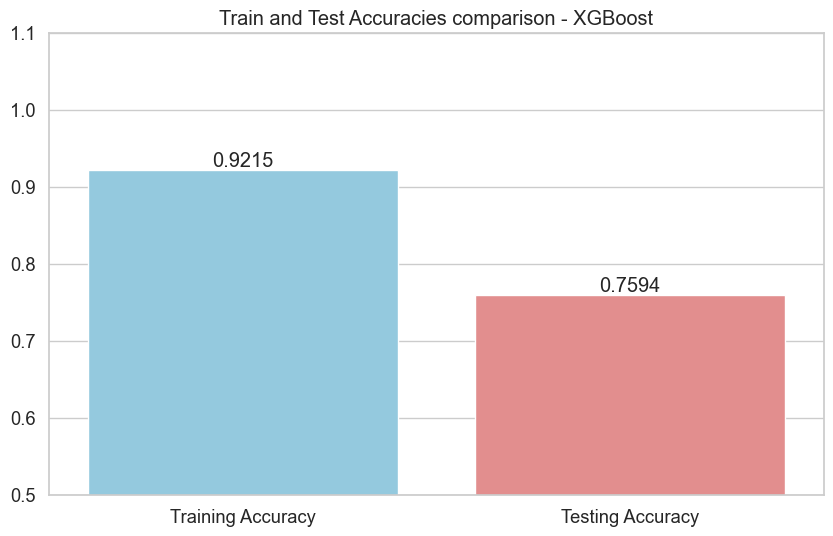

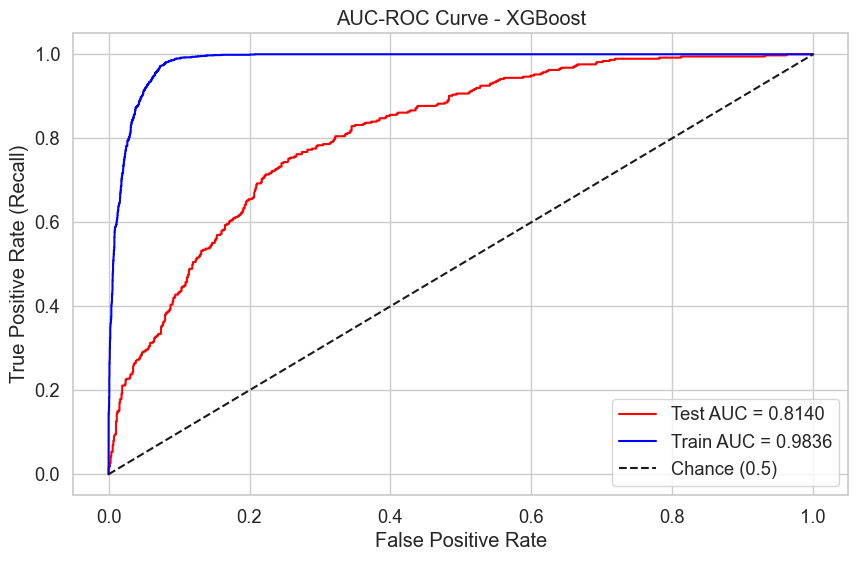

In [47]:
xgb_results = evaluate_model(xgb_pipeline, X_train, y_train, X_test, y_test, "XGBoost")

There is less overfitting than random forest and knn

#### 5. LightGBM

In [48]:
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', LGBMClassifier(random_state=42, metric='auc', n_estimators=100, scale_pos_weight=scale_pos_weight_value, verbosity=-1))
])

lgbm_pipeline.fit(X_train, y_train)

c:\Users\Youssif\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['tenure',
                                                   'MonthlyCharges'])])),
                ('model',
                 LGBMClassifier(metric='auc', random_state=42,
                                scale_pos_weight=np.float64(2.768561872909699),
                                verbosity=-1))])


====================== LightGBM EVALUATION ======================

Classification Report (Test Data)
              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1035
           1       0.54      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

| Metric     | Training Set    | Testing Set     |
-----------------------------------------------
| Accuracy   | 0.8520              | 0.7608              |
| F1 Score   | 0.7723              | 0.6235              |
| AUC-ROC    | 0.9414              | 0.8353              |


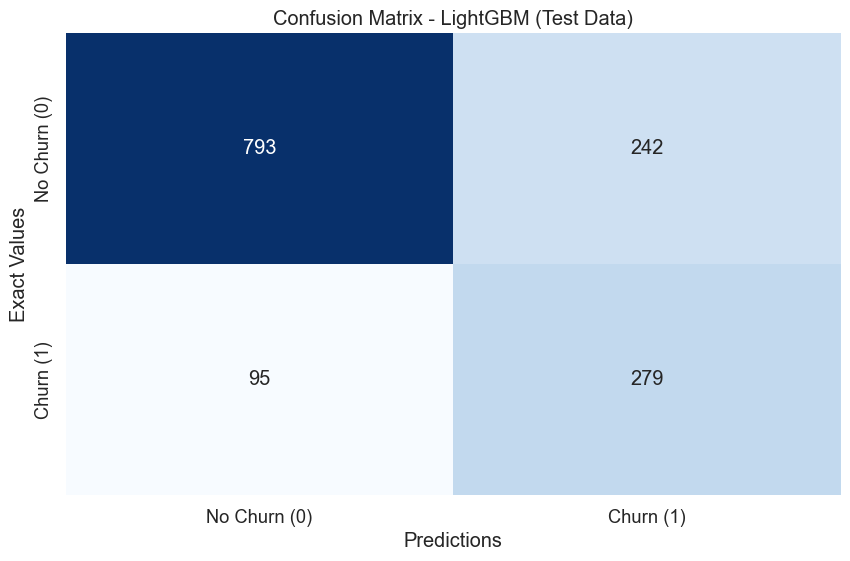

C:\Users\Youssif\AppData\Local\Temp\ipykernel_21324\2738180666.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=accuracies, palette=['skyblue', 'lightcoral'])


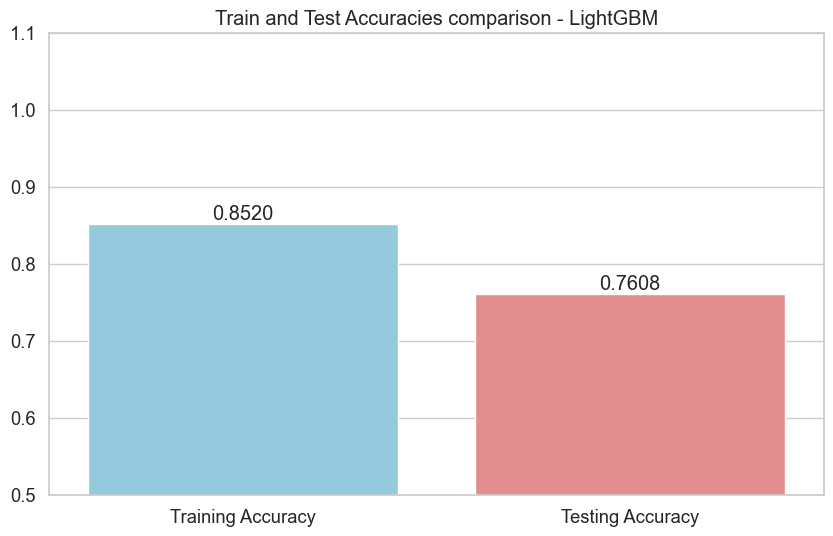

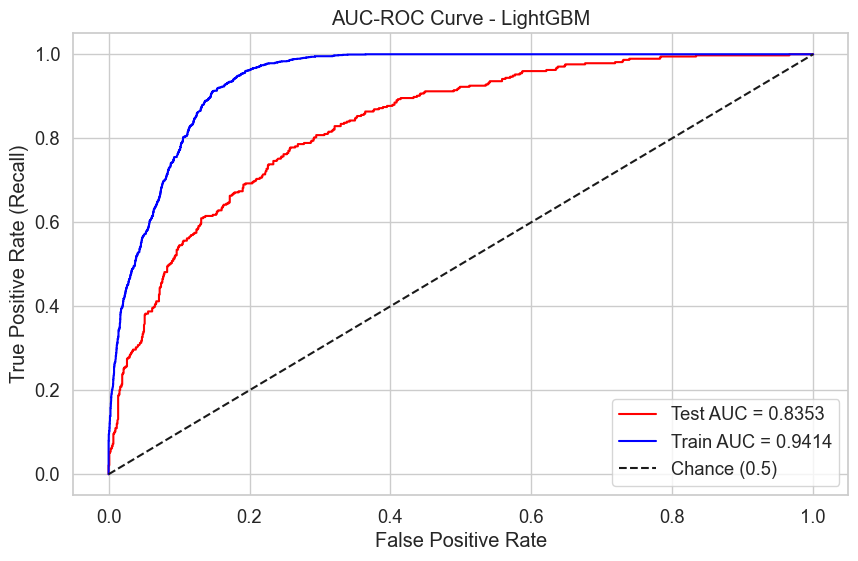

In [49]:
lgbm_results = evaluate_model(lgbm_pipeline, X_train, y_train, X_test, y_test, "LightGBM")

we can notice here that there is still overfittin but it is much less than previews algorithms

## Comparing Baseline Models

| Model | AUC |
|-------|-----|
| Logestic Regression | 0.8326 |
| K Nearest neighbors | 0.8326 |
| Random Forest | 0.8149 |
| XGBoost | 0.7516 |
| LightGBM | 0.8140 |

| Model                          |   Train Accuracy |   Test Accuracy |   Test F1 Score |   Test AUC-ROC |   Test Recall (Churn) |
|:-------------------------------|-----------------:|----------------:|----------------:|---------------:|----------------------:|
| Logestic Regression (Baseline) |         0.743344 |        0.731015 |        0.610483 |       0.832638 |              0.794118 |
| XGBoost                        |         0.921548 |        0.759404 |        0.605355 |       0.813988 |              0.695187 |
| Random Forest (base model)     |         0.996983 |        0.771469 |        0.522255 |       0.814871 |              0.470588 |
| KNN (base model)               |         0.99716  |        0.745209 |        0.510232 |       0.751243 |              0.5      |
| LightGBM                       |         0.85197  |        0.760823 |        0.623464 |       0.83529  |              0.745989 |


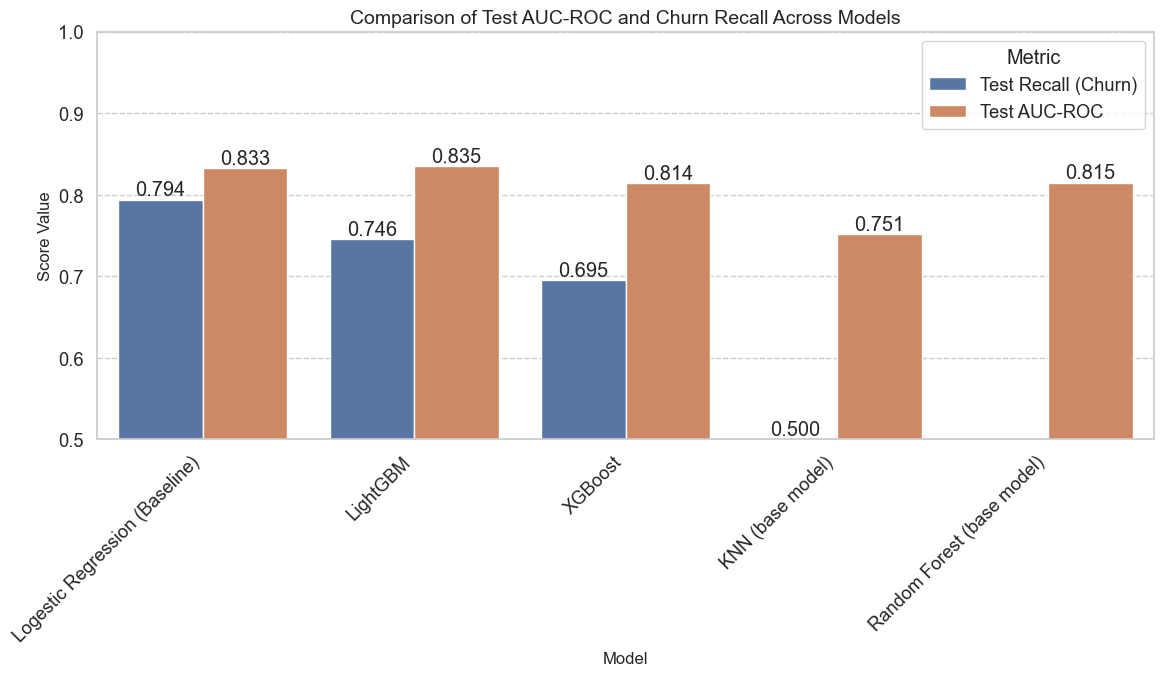

In [50]:
all_results = pd.concat([
        logreg_results,
        xgb_results,
        rf_results,
        knn_results,
        lgbm_results 
    ], ignore_index=True)


print(all_results.head().to_markdown(index=False))



# Melt
comparison_df = all_results[['Model', 'Test AUC-ROC', 'Test Recall (Churn)']]
melted_df = comparison_df.melt(
    id_vars='Model',
    value_vars=['Test AUC-ROC', 'Test Recall (Churn)'],
    var_name='Metric',
    value_name='Value'
)

# Bar Plot
plt.figure(figsize=(12, 7))
sns.barplot(
    x='Model',
    y='Value',
    hue='Metric',
    data=melted_df.sort_values(by=['Metric', 'Value'], ascending=[False, False]))
plt.title('Comparison of Test AUC-ROC and Churn Recall Across Models', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score Value', fontsize=12)
plt.ylim(0.5, 1.0) 

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

As we can see:
- `LightGBM` has the highest auc
- `Logestic regression` has the higest Recall and it's AUC score is so close to `LightGBM`
- `XGBoost` was intermediate
- `KNN` did the worst between all of them
- `Random forest` has good AUC score but really bad at recall

So we will choose only three models to do some hyperparameters tuning which will be the best three which are:
1. LightGBM
2. Logestic Regression
3. XGBoost

# Hyperparameters Tuning

## Hyperparameter Tuning
Now that we've established baselines, let's try to improve our best models.

**Strategy:**
1. **RandomizedSearchCV**: Quickly explore a wide range of parameters.
2. **GridSearchCV**: Fine-tune the promising areas identified by random search.

We will do two-phase hyper tuning strategey for each model we chose wich follows this approach:
1. RandomizedSearchCV
   - To go explore a wide hyperparameter space to find the best region
2. GridSearchCV
   - To explore the best regions found in RandomizedSearchCV to find the best hyper parameters
  
We are going through this approach since each step has it pros and cons:
1. RandomizedSearchCV
    - pros: Quickly explore wide ranges of hyperparameter space and faster significantly faster than GridSearchCV
    - cons: Since it tries random combinations of the hyperparameters it can't find exactly the best hyperparameters combination
2. GridSearchCV
   - Pros: It finds exactly the best hyperparameters
   - cons: Can't explore wide ranges of hyperparameters as it takes a lot of time since it tries every combination possible for the given hyper parameters

conclusion:
By using this strategy we take the pros of RandomSearchCV and GridSearchCV and avoiding their disadvantages to get the best hyperparameters for the models


In [51]:
# We will create a function to print the best parameters and scores
def best_parameters(model):
    print("Best Parameters:")
    for key, value in model.best_params_.items():
        print(f"{key}: {value}")
        
    print('=' * 50)
    print(f"Best AUC (Cross-Validation): {model.best_score_:.4f}")

    return {'best_params': model.best_params_, 'auc': model.best_score_}

## LightGBM Hyperparameters Tuning 

### 1. RandomizedSearchCV

In [52]:
# We will create the baseline model again with metric='auc'
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('model', LGBMClassifier(
        random_state=42,
        metric='auc',
        scale_pos_weight=scale_pos_weight_value, 
        verbosity=-1
    ))
])



In [53]:
param_dist_lgbm = {
    'model__n_estimators': randint(100, 500),           
    'model__max_depth': randint(3, 15),                 
    'model__learning_rate': uniform(0.01, 0.2),        
    'model__num_leaves': randint(10, 100),               
    'model__subsample': uniform(0.7, 0.3),              
    'model__colsample_bytree': uniform(0.7, 0.3),       
    'model__min_child_samples': randint(10, 60),        
    'model__reg_alpha': uniform(0, 1.5),                
    'model__reg_lambda': uniform(0, 1.5)                
}

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=param_dist_lgbm,
    n_iter=50, 
    scoring='roc_auc', 
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1,
)

random_search_lgbm.fit(X_train, y_train)

print("Best Parameters:")
for key, value in random_search_lgbm.best_params_.items():
    print(f"{key}: {value}")
    
print('=' * 50)
print(f"Best AUC (Cross-Validation): {random_search_lgbm.best_score_:.4f}")

Best Parameters:
model__colsample_bytree: 0.8607324052224274
model__learning_rate: 0.02805795401088166
model__max_depth: 3
model__min_child_samples: 18
model__n_estimators: 223
model__num_leaves: 68
model__reg_alpha: 0.27977776559978135
model__reg_lambda: 0.061162712332145874
model__subsample: 0.8772678829564725
Best AUC (Cross-Validation): 0.8466


### 2. GridSearchCV

In [54]:

param_grid_lgbm = {
    # num_leaves
    'model__num_leaves': [
        math.floor(random_search_lgbm.best_params_['model__num_leaves'] - 10), 
        random_search_lgbm.best_params_['model__num_leaves'], 
        math.ceil(random_search_lgbm.best_params_['model__num_leaves'] + 10)
    ],
    
    # max_depth
    'model__max_depth': [
        math.floor(random_search_lgbm.best_params_['model__max_depth'] - 1), 
        random_search_lgbm.best_params_['model__max_depth'], 
        math.ceil(random_search_lgbm.best_params_['model__max_depth'] + 1)
    ],
    
    # n_estimators
    'model__n_estimators': [
        math.floor(random_search_lgbm.best_params_['model__n_estimators'] - 25), 
        random_search_lgbm.best_params_['model__n_estimators'], 
        math.ceil(random_search_lgbm.best_params_['model__n_estimators'] + 25)
    ],

    # learning_rate
    'model__learning_rate': [
        random_search_lgbm.best_params_['model__learning_rate'] * 0.8, 
        random_search_lgbm.best_params_['model__learning_rate'], 
        random_search_lgbm.best_params_['model__learning_rate'] * 1.2
    ],
    
    # min_child_samples
    'model__min_child_samples': [
        math.floor(random_search_lgbm.best_params_['model__min_child_samples'] - 5), 
        random_search_lgbm.best_params_['model__min_child_samples'], 
        math.ceil(random_search_lgbm.best_params_['model__min_child_samples'] + 5)
    ],
    
    'model__subsample': [random_search_lgbm.best_params_['model__subsample']],
    'model__colsample_bytree': [random_search_lgbm.best_params_['model__colsample_bytree']],
    'model__reg_alpha': [random_search_lgbm.best_params_['model__reg_alpha']],
    'model__reg_lambda': [random_search_lgbm.best_params_['model__reg_lambda']]
}

grid_search_lgbm = GridSearchCV(
    estimator=lgbm_pipeline,
    param_grid=param_grid_lgbm,
    scoring='roc_auc',
    cv=5,
    verbose=0, 
    n_jobs=-1
)




grid_search_lgbm.fit(X_train, y_train)

                     
print("Best Parameters:")
for key, value in random_search_lgbm.best_params_.items():
    print(f"{key}: {value}")
    
print('=' * 50)
print(f"Best AUC (Cross-Validation): {random_search_lgbm.best_score_:.4f}")

Best Parameters:
model__colsample_bytree: 0.8607324052224274
model__learning_rate: 0.02805795401088166
model__max_depth: 3
model__min_child_samples: 18
model__n_estimators: 223
model__num_leaves: 68
model__reg_alpha: 0.27977776559978135
model__reg_lambda: 0.061162712332145874
model__subsample: 0.8772678829564725
Best AUC (Cross-Validation): 0.8466


### Evaluation


====================== LightGBM (Optimized) EVALUATION ======================

Classification Report (Test Data)
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409

| Metric     | Training Set    | Testing Set     |
-----------------------------------------------
| Accuracy   | 0.8592              | 0.8437              |
| F1 Score   | 0.6353              | 0.6173              |
| AUC-ROC    | 0.8592              | 0.8437              |


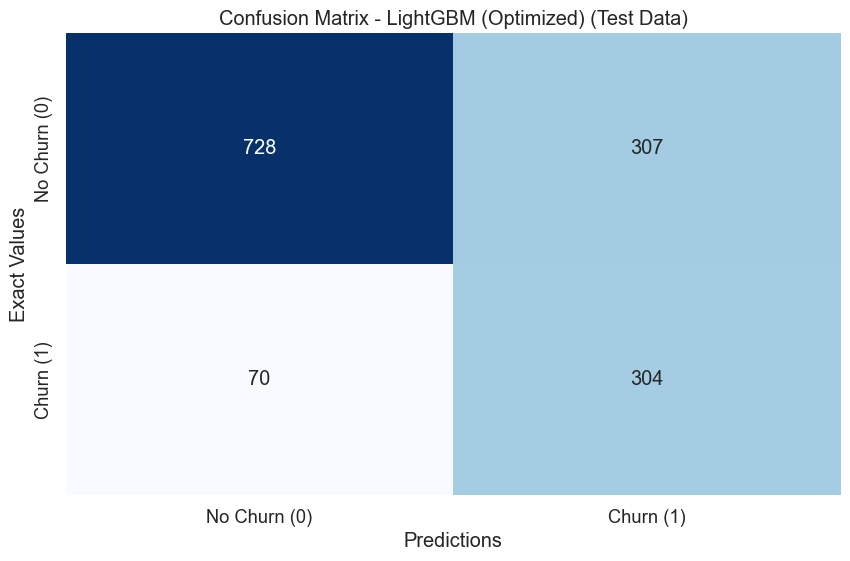

C:\Users\Youssif\AppData\Local\Temp\ipykernel_21324\2738180666.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=accuracies, palette=['skyblue', 'lightcoral'])


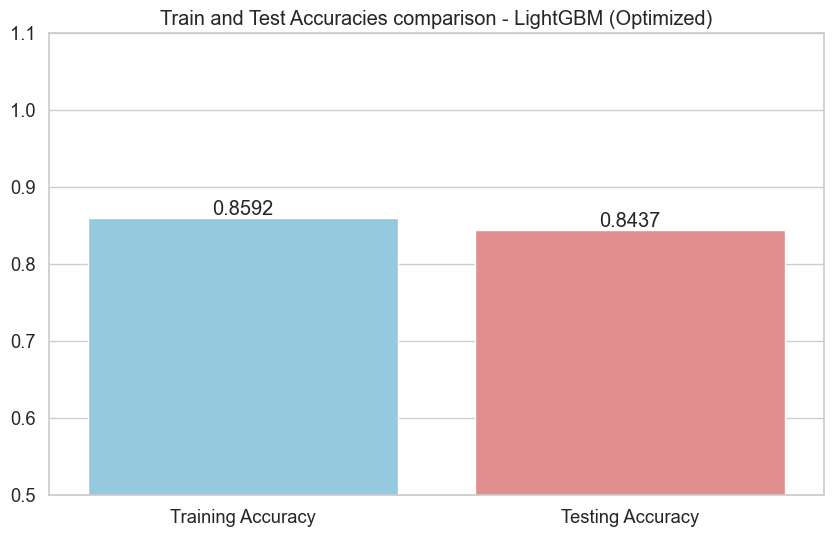

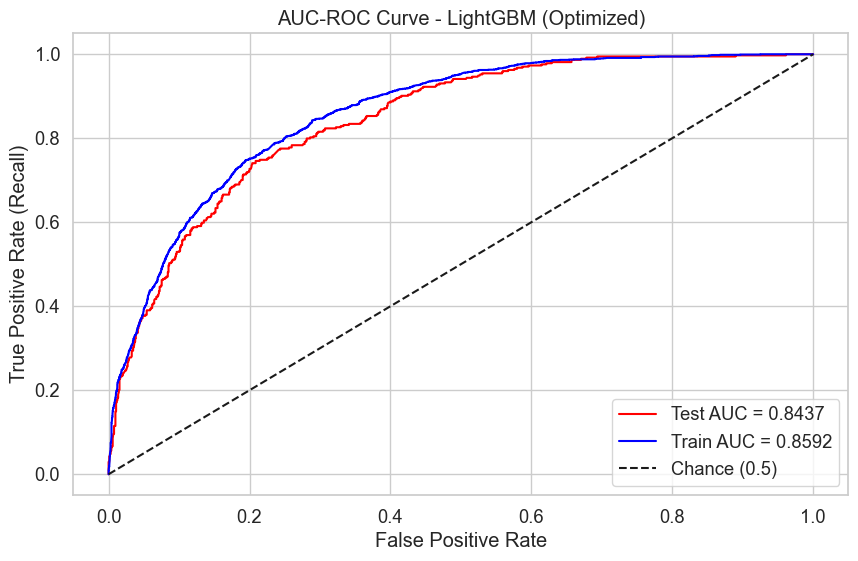

In [55]:
lgbm_results = evaluate_model(grid_search_lgbm, X_train, y_train, X_test, y_test, "LightGBM (Optimized)")

## XGBoost Hyperparameters Tuning

In [56]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='auc'))
])

### 1. RandomSearchCV

In [57]:
param_dist_xgb = {
    'model__n_estimators': randint(100, 600),
    'model__max_depth': randint(3, 15),
    'model__learning_rate': uniform(0.01, 0.25),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__colsample_bylevel': uniform(0.6, 0.4),
    'model__gamma': uniform(0, 1.0),               
    'model__reg_alpha': uniform(0, 2.0),           
    'model__reg_lambda': uniform(0, 2.0),          
    'model__min_child_weight': randint(1, 10)      
}

xgb_random = RandomizedSearchCV(xgb_pipeline, param_dist_xgb, n_iter=50, 
                                scoring='roc_auc', cv=5, verbose=0, n_jobs=-1, random_state=42)

xgb_random.fit(X_train, y_train)

best_rand_xgb_params = best_parameters(xgb_random)

Best Parameters:
model__colsample_bylevel: 0.8733054075301833
model__colsample_bytree: 0.8439986631130484
model__gamma: 0.8331949117361643
model__learning_rate: 0.05334116337694302
model__max_depth: 3
model__min_child_weight: 4
model__n_estimators: 149
model__reg_alpha: 1.325044568707964
model__reg_lambda: 0.6234221521788219
model__subsample: 0.8080272084711243
Best AUC (Cross-Validation): 0.8482


### 2. GridSearchCV

In [58]:
param_grid_xgb = {
    'model__max_depth': [math.floor(xgb_random.best_params_['model__max_depth']-1), 
                         xgb_random.best_params_['model__max_depth'], 
                         math.ceil(xgb_random.best_params_['model__max_depth']+1)],
    
    'model__learning_rate': [xgb_random.best_params_['model__learning_rate']*0.8, 
                             xgb_random.best_params_['model__learning_rate'], 
                             xgb_random.best_params_['model__learning_rate']*1.2],
    
    'model__n_estimators': [xgb_random.best_params_['model__n_estimators']-50, 
                            xgb_random.best_params_['model__n_estimators'], 
                            xgb_random.best_params_['model__n_estimators']+50],
    
    'model__subsample': [xgb_random.best_params_['model__subsample']],
    'model__colsample_bytree': [xgb_random.best_params_['model__colsample_bytree']],
    'model__gamma': [xgb_random.best_params_['model__gamma']],
    'model__reg_alpha': [xgb_random.best_params_['model__reg_alpha']],
    'model__reg_lambda': [xgb_random.best_params_['model__reg_lambda']],
    'model__min_child_weight': [xgb_random.best_params_['model__min_child_weight']]
}

xgb_grid = GridSearchCV(xgb_pipeline, param_grid_xgb, scoring='roc_auc', cv=5, verbose=0, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

best_grid_xgb_params = best_parameters(xgb_grid)

Best Parameters:
model__colsample_bytree: 0.8439986631130484
model__gamma: 0.8331949117361643
model__learning_rate: 0.05334116337694302
model__max_depth: 2
model__min_child_weight: 4
model__n_estimators: 199
model__reg_alpha: 1.325044568707964
model__reg_lambda: 0.6234221521788219
model__subsample: 0.8080272084711243
Best AUC (Cross-Validation): 0.8487


### Evaluation


====================== XGBoost (Optimized) EVALUATION ======================

Classification Report (Test Data)
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

| Metric     | Training Set    | Testing Set     |
-----------------------------------------------
| Accuracy   | 0.8602              | 0.8461              |
| F1 Score   | 0.6050              | 0.5805              |
| AUC-ROC    | 0.8602              | 0.8461              |


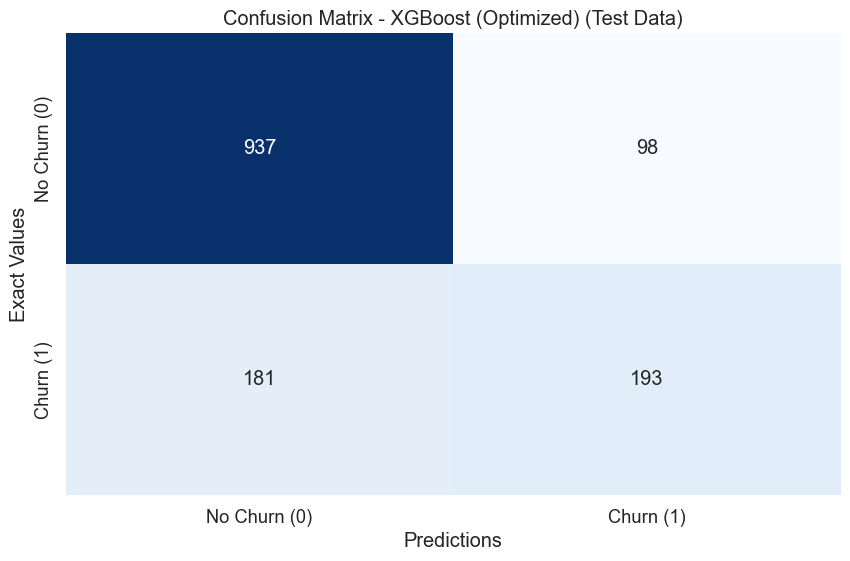

C:\Users\Youssif\AppData\Local\Temp\ipykernel_21324\2738180666.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=accuracies, palette=['skyblue', 'lightcoral'])


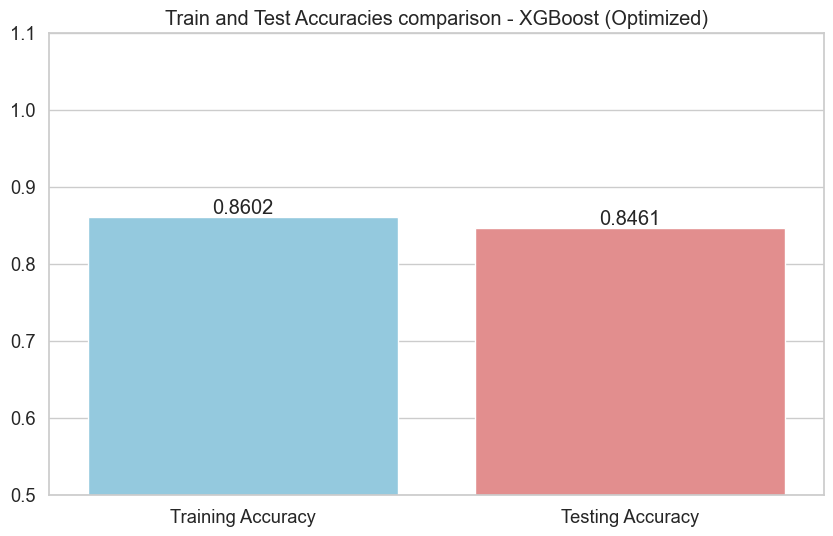

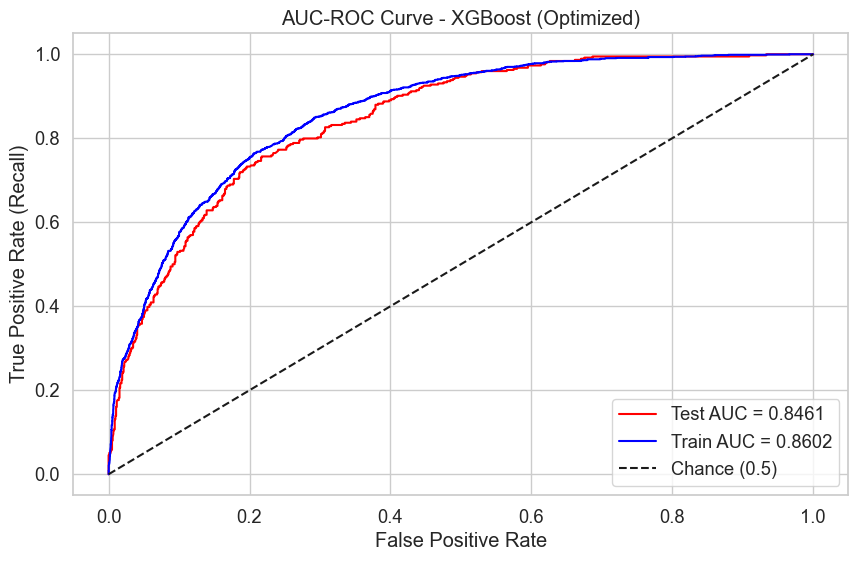

In [59]:
xgboost_results = evaluate_model(xgb_grid, X_train, y_train, X_test, y_test, "XGBoost (Optimized)")

## Logestic Regression Hyperparameters Tuning

In [60]:
log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=5000))
])

### 1. RandomizedSearchCV

In [61]:
param_dist_log = {
    'model__C': uniform(0.001, 50),
    'model__penalty': ['l1', 'l2'],          
    'model__solver': ['liblinear', 'saga'],  
    'model__class_weight': [None, 'balanced'],
    'model__fit_intercept': [True, False],
    'model__tol': [1e-4, 1e-3, 1e-2]
}

log_random = RandomizedSearchCV(
    log_pipeline, 
    param_dist_log, 
    n_iter=30, 
    scoring='roc_auc', 
    cv=5, 
    verbose=0, 
    n_jobs=-1, 
    random_state=42
)

log_random.fit(X_train, y_train)

best_rand_lr_params = best_parameters(log_random)

Best Parameters:
model__C: 7.047211248738132
model__class_weight: None
model__fit_intercept: True
model__penalty: l1
model__solver: liblinear
model__tol: 0.01
Best AUC (Cross-Validation): 0.8406


### 2. GridSearchCV

In [62]:
param_grid_log = {
    'model__C': [log_random.best_params_['model__C']*0.8, 
                 log_random.best_params_['model__C'], 
                 log_random.best_params_['model__C']*1.2],
    'model__penalty': [log_random.best_params_['model__penalty']],
    'model__solver': [log_random.best_params_['model__solver']],
    'model__class_weight': [log_random.best_params_['model__class_weight']],
    'model__tol': [log_random.best_params_['model__tol']]
}


log_grid = GridSearchCV(log_pipeline, param_grid_log, scoring='roc_auc', cv=5, verbose=0, n_jobs=-1)

log_grid.fit(X_train, y_train)

best_grid_lr_params = best_parameters(log_grid)

Best Parameters:
model__C: 8.456653498485759
model__class_weight: None
model__penalty: l1
model__solver: liblinear
model__tol: 0.01
Best AUC (Cross-Validation): 0.8408


### Evaluation


====================== Logestic Regression (Optimized) EVALUATION ======================

Classification Report (Test Data)
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

| Metric     | Training Set    | Testing Set     |
-----------------------------------------------
| Accuracy   | 0.8429              | 0.8339              |
| F1 Score   | 0.5934              | 0.5677              |
| AUC-ROC    | 0.8429              | 0.8339              |


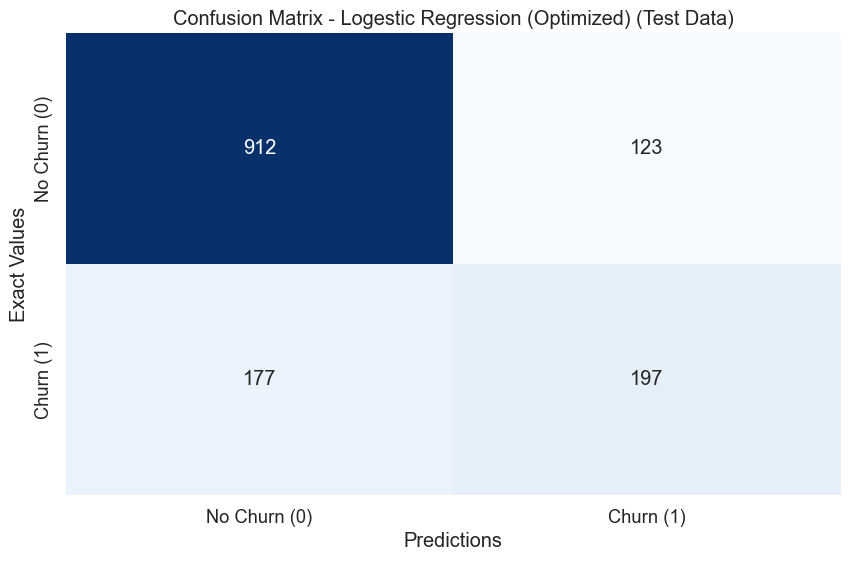

C:\Users\Youssif\AppData\Local\Temp\ipykernel_21324\2738180666.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=accuracies, palette=['skyblue', 'lightcoral'])


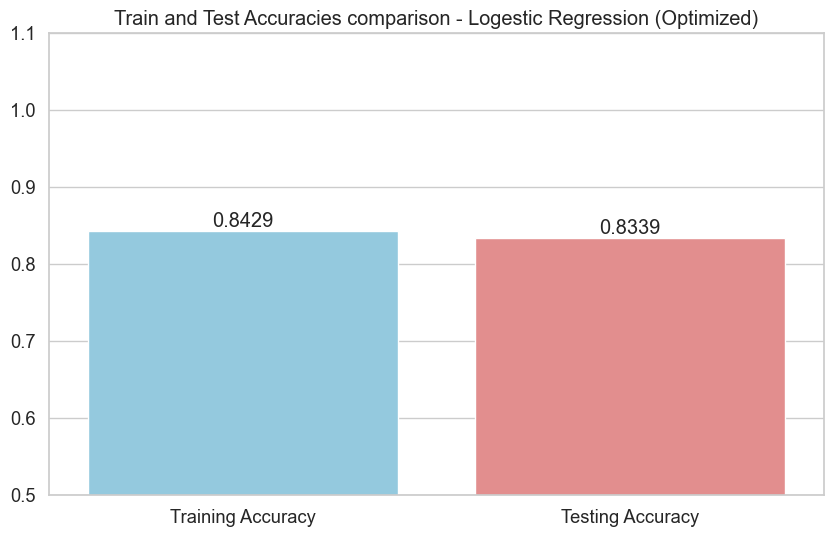

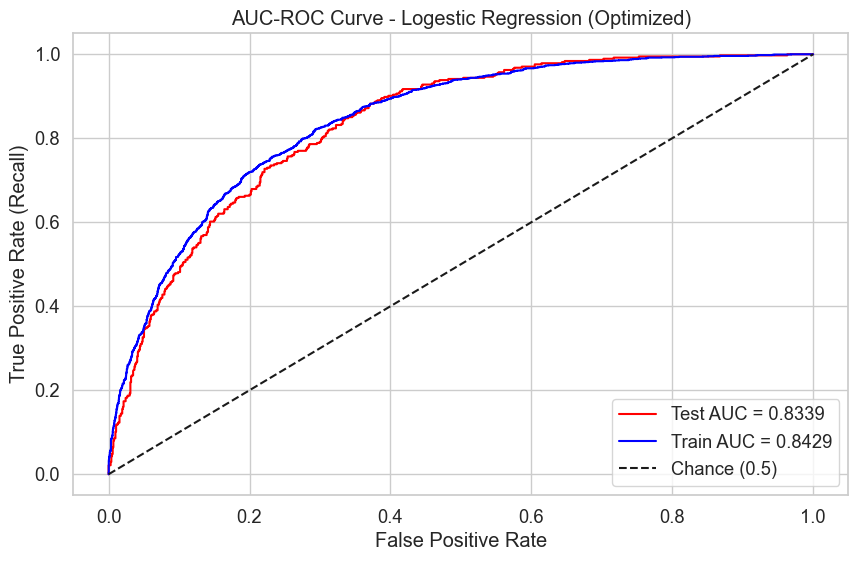

In [63]:
lr_results = evaluate_model(log_grid, X_train, y_train, X_test, y_test, "Logestic Regression (Optimized)")

# Comparing models

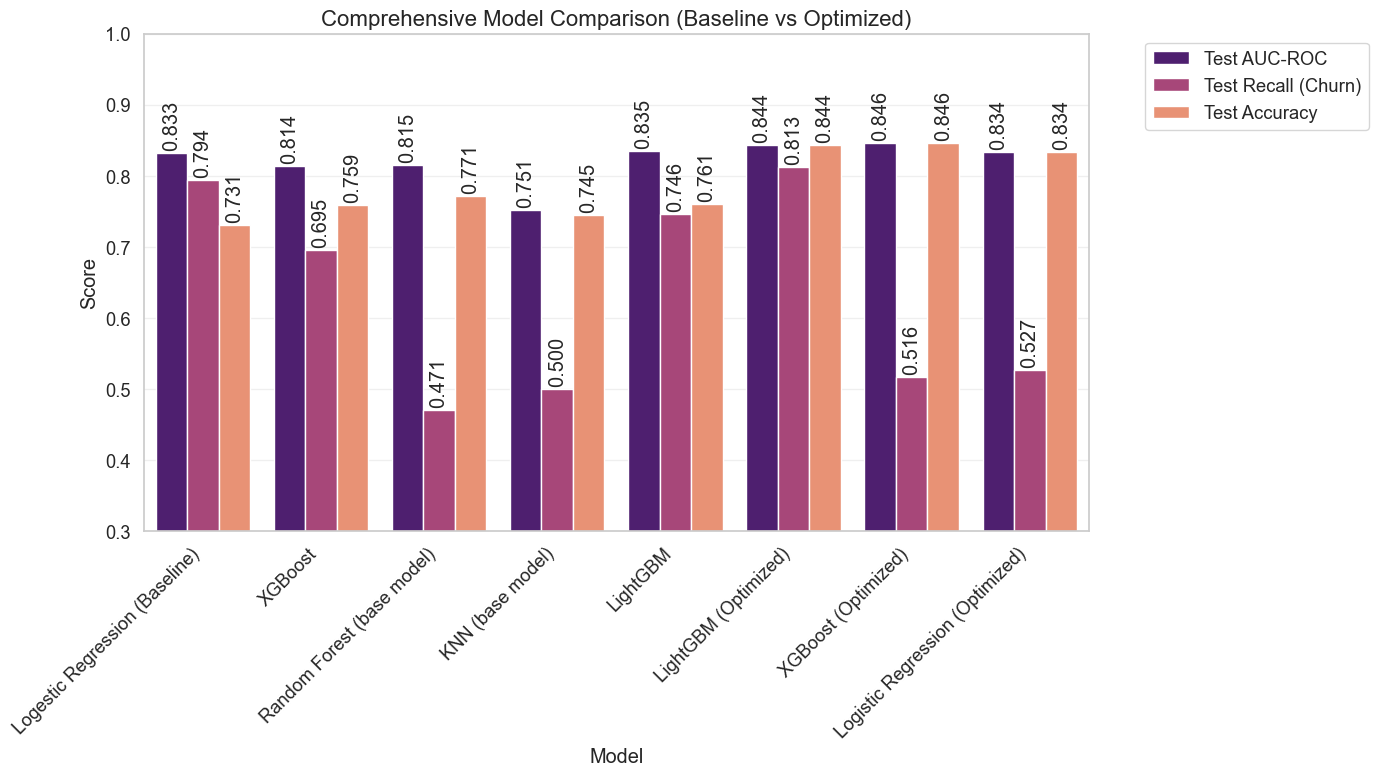

,Model,Train Accuracy,Test Accuracy,Test F1 Score,Test AUC-ROC,Test Recall (Churn)
6,XGBoost (Optimized),0.860174,0.846053,0.580451,0.846053,0.516043
5,LightGBM (Optimized),0.859177,0.843654,0.617259,0.843654,0.812834
4,LightGBM,0.851970,0.760823,0.623464,0.835290,0.745989
7,Logistic Regression (Optimized),0.842947,0.833891,0.567723,0.833891,0.526738
0,Logestic Regression (Baseline),0.743344,0.731015,0.610483,0.832638,0.794118
2,Random Forest (base model),0.996983,0.771469,0.522255,0.814871,0.470588
1,XGBoost,0.921548,0.759404,0.605355,0.813988,0.695187
3,KNN (base model),0.997160,0.745209,0.510232,0.751243,0.500000


In [64]:
# 1. Combine all results
# 'all_results' contains our baseline models (from earlier cell)
# 'lgbm_results', 'xgboost_results', 'lr_results' contain the OPTIMIZED versions from later cells

# Ensure optimized results have distinct names for the plot
lgbm_results['Model'] = "LightGBM (Optimized)"
xgboost_results['Model'] = "XGBoost (Optimized)"
lr_results['Model'] = "Logistic Regression (Optimized)"

final_comparison = pd.concat([
    all_results,       # Baselines
    lgbm_results,      # Opt
    xgboost_results,   # Opt
    lr_results         # Opt
], ignore_index=True)

# Remove duplicates if any (in case re-runs happened)
final_comparison = final_comparison.drop_duplicates(subset=['Model'])

# 2. Melt for Plotting
metrics_to_plot = ['Test AUC-ROC', 'Test Recall (Churn)', 'Test F1-Score (Churn)', 'Test Accuracy']
# Filter to available columns just in case
cols = ['Model'] + [c for c in metrics_to_plot if c in final_comparison.columns]

melted_df = final_comparison[cols].melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

# 3. Plot
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=melted_df,
    x='Model',
    y='Score',
    hue='Metric',
    palette='magma'
)

plt.title('Comprehensive Model Comparison (Baseline vs Optimized)', fontsize=16)
plt.ylim(0.3, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, rotation=90,)


plt.show()

# Display Table
final_comparison.sort_values(by='Test AUC-ROC', ascending=False)

# Results
Here are the final performance metrics for all models we tested — both the untuned baselines and the hyperparameter-tuned versions. The table is sorted by Test AUC-ROC (our primary metric for this imbalanced churn problem, as it measures overall discrimination ability).

| Model                        | Train Accuracy | Test Accuracy | Test F1 Score (Churn) | Test AUC-ROC | Test Recall (Churn) |
|-------------------------------|----------------|---------------|-----------------------|---------------|--------------------|
| XGBoost (Optimized)           | 0.860          | 0.846         | 0.580                 | 0.846         | 0.516              |
| LightGBM (Optimized)          | 0.859          | 0.844         | 0.617                 | 0.844         | 0.813              |
| Logistic Regression (Optimized)| 0.843         | 0.833         | 0.573                 | 0.833         | 0.524              |
| LightGBM (Baseline)           | 0.852          | 0.761         | 0.623                 | 0.835         | 0.746              |
| Logistic Regression (Baseline)| 0.743          | 0.731         | 0.610                 | 0.833         | 0.794              |
| Random Forest (Baseline)      | 0.997          | 0.771         | 0.522                 | 0.815         | 0.471              |
| XGBoost (Baseline)            | 0.922          | 0.759         | 0.605                 | 0.814         | 0.695              |
| KNN (Baseline)                | 0.997          | 0.745         | 0.510                 | 0.751         | 0.500              |


Key observations from the numbers:

- Hyperparameter tuning consistently improved generalization (smaller gap between train and test accuracy).
- Optimized models occupy the top 3 spots — clear win for tuning!
- LightGBM (Optimized) achieves the highest recall (0.813), meaning it catches the most actual churners.
- XGBoost (Optimized) leads in overall AUC-ROC and test accuracy.

# Conclusion & Winner

After exploring the data, building baselines, and carefully tuning three promising models, we have reliable churn predictors ready for real-world use.

**The winner is: Optimized LightGBM**
Yes, XGBoost has a slightly higher AUC-ROC (0.846 vs. 0.844), but in customer churn prediction, recall on the churn class is often the most critical metric and LightGBM dominates here with an impressive 0.813 recall.


### Why recall matters most in churn prediction

- **Business cost asymmetry:** Missing a customer who is about to churn (false negative) is far more expensive than incorrectly flagging a loyal customer (false positive).
    - If we fail to identify a churner, we lose that customer's lifetime value, potentially thousands of dollars in recurring revenue.
    - If we mistakenly target a non-churner with a retention offer (discount, free month, etc.), the cost is usually small and temporary.

- Proactive retention: The whole point of churn modeling is to intervene early. High recall means we catch significantly more at-risk customers, giving the company more opportunities to save them through personalized offers, better support, or service improvements.
- Real-world impact: LightGBM's 0.813 recall means it identifies ~81% of actual churners, that's ~30% more than XGBoost's 0.516 in relative terms. Even with a tiny drop in precision, the extra saved customers easily justify the choice.

LightGBM also delivers a strong F1-score (0.617) and very competitive AUC/accuracy, showing it's not sacrificing too much overall performance for that recall boost.

Runner-up: Optimized XGBoost remains excellent if the business wants the absolute best discrimination (AUC) with fewer false positives.

**Final recommendation**
Deploy the Optimized LightGBM model for maximum retention impact. Pair it with SHAP explanations to understand why each customer is flagged, enabling targeted and effective interventions.

Thanks for following this analysis! This model can genuinely help a telco reduce churn and protect revenue. Feel free to experiment further, maybe try class weights, SMOTE, or ensembling the two top models for an even sweeter spot.